# 🛍️ Supply Chain Bottleneck Detection
## Beautica Store — Internal Operational Audit

**Author:** Muhammad Ali Fikri

___

# Chapter 1 — Business Understanding

---

**1.1 BACKGROUND**

**Beautica Store** is a beauty and makeup startup based in Surabaya, Indonesia. Since its early days, the company has been growing steadily — expanding its product range, onboarding new suppliers, and reaching more customers across the region.

But behind the promising sales numbers, cracks are beginning to show on the operational side. Deliveries are inconsistent, stock levels are hard to predict, and costs seem to keep creeping up without a clear explanation. The management team has been sensing something is off — they just haven't had the data to back it up.

That changed when **investors requested a full operational audit** before considering the next round of funding. Suddenly, the question wasn't just *"are we growing?"* — it became *"are we running this efficiently enough to scale?"*

This project is the answer to that question.

As the internal **Data Analyst** at Beautica Store, I was tasked by **Management, the Supply Chain Manager, and the Supply Chain Supervisor** to conduct a thorough analysis of our supply chain data — identifying bottlenecks, inefficiencies, and areas that need immediate attention.

**1.2 PROBLEM STATEMENT**

Despite consistent revenue, Beautica Store is facing several operational challenges that could hinder long-term growth and investor confidence:


1. **Supplier Reliability** Are all our suppliers performing up to standard, or are some quietly dragging us down? 
2. **Delivery Delays** Where and why are delays happening — and is there a pattern we're missing?
3. **Inventory Risk** Are we at risk of stockouts on high-demand products, or sitting on dead stock?
4. **Product Quality** How much revenue are we losing due to defective products?
5. **Cost Efficiency** Are we spending money in the right places, or are there leaks in our cost structure?

Without answering these questions, it's difficult to make informed decisions — and even harder to convince investors that Beautica Store is ready to scale.

**1.3 PROJECT GOALS & OBJECTIVES**

#### 🎯 Main Goal
Detect and document the key bottlenecks in Beautica Store's supply chain, and provide **actionable recommendations** that management can act on immediately.

#### 📌 Objectives

**1. Supplier Performance Analysis**  
Evaluate each supplier based on lead time, defect rate, and cost — and flag underperformers.

**2. Delivery Delay Pattern Analysis**  
Identify patterns in shipping delays across carriers, routes, and transportation modes.

**3. Inventory & Stock Risk Analysis**  
Spot products at risk of stockout or overstock, and assess how well order quantities match demand.

**4. Quality & Defect Impact Analysis**  
Quantify the revenue impact of defects and trace them back to the responsible suppliers.

**5. Cost Inefficiency Analysis**  
Break down the full cost structure — manufacturing, shipping, and operational — to find where money is being wasted.

---


# Chapter 2 — Data Understanding & Preparation

---

#### 2.1 IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('All libraries loaded successfully!')

All libraries loaded successfully!


#### 2.2 LOAD DATASET 

In [2]:
# Load dataset
df = pd.read_csv('supply_chain_data.csv')  # 📝 update with your actual filename

print(f'Dataset loaded successfully!')

Dataset loaded successfully!


In [3]:
#showing at the first few rows
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,Shipping times,Shipping carriers,Shipping costs,Supplier name,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.81,55,802,8662.00,Non-binary,58,7,96,4,Carrier B,2.96,Supplier 3,Mumbai,29,215,29,46.28,Pending,0.23,Road,Route B,187.75
1,skincare,SKU1,14.84,95,736,7460.90,Female,53,30,37,2,Carrier A,9.72,Supplier 3,Mumbai,23,517,30,33.62,Pending,4.85,Road,Route B,503.07
2,haircare,SKU2,11.32,34,8,9577.75,Unknown,1,10,88,2,Carrier B,8.05,Supplier 1,Mumbai,12,971,27,30.69,Pending,4.58,Air,Route C,141.92
3,skincare,SKU3,61.16,68,83,7766.84,Non-binary,23,13,59,6,Carrier C,1.73,Supplier 5,Kolkata,24,937,18,35.62,Fail,4.75,Rail,Route A,254.78
4,skincare,SKU4,4.81,26,871,2686.51,Non-binary,5,3,56,8,Carrier A,3.89,Supplier 1,Delhi,5,414,3,92.07,Fail,3.15,Air,Route A,923.44


In [4]:
df.shape

(100, 24)

In [5]:
#show dataset columns name
df.columns

Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'Costs'],
      dtype='object')

In [6]:
#show dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

#### 2.3 ABOUT DATASET
The dataset used in this project is the **Supply Chain Analytics Dataset**, sourced from a Fashion & Beauty startup's operational records — closely mirroring the kind of data Beautica Store works with daily.

| Detail | Info |
|---|---|
| **Source** | Supply Chain Analytics Dataset (Kaggle) |
| **Domain** | Beauty & Makeup / Fashion |
| **Total Records** | 100 rows |
| **Total Features** | 24 columns |


Here's a breakdown of all 24 columns and what they represent:

| Column | Description |
|---|---|
| `Product Type` | Category of the makeup product (e.g., skincare, haircare) |
| `SKU` | Unique identifier for each product |
| `Price` | Selling price per unit |
| `Availability` | Current availability status of the product |
| `Number of products sold` | Total units sold |
| `Revenue generated` | Total revenue from sales |
| `Customer demographics` | Target customer segment |
| `Stock levels` | Current inventory quantity |
| `Lead times` | Total lead time from order to delivery |
| `Order quantities` | Number of units ordered per transaction |
| `Shipping times` | Actual time taken to ship the product |
| `Shipping carriers` | Name of the carrier/logistics provider |
| `Shipping costs` | Cost associated with shipping |
| `Supplier name` | Name of the product supplier |
| `Location` | Supplier's geographical location |
| `Lead time` | Supplier-side lead time |
| `Production volumes` | Number of units produced |
| `Manufacturing lead time` | Time taken to manufacture the product |
| `Manufacturing costs` | Cost of manufacturing per unit |
| `Inspection results` | Quality inspection outcome (Pass/Fail/Pending) |
| `Defect rates` | Percentage of defective units |
| `Transportation modes` | Mode used for shipping (Air, Sea, Road, Rail) |
| `Routes` | Shipping route taken |
| `Costs` | General/total operational cost |


#### 2.3 DATASET INSPECTION

In [7]:
# Statistical summary for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,100.00,49.46,31.17,1.70,19.60,51.24,77.20,99.17
Availability,100.00,48.40,30.74,1.00,22.75,43.50,75.00,100.00
Number of products sold,100.00,460.99,303.78,8.00,184.25,392.50,704.25,996.00
Revenue generated,100.00,5776.05,2732.84,1061.62,2812.85,6006.35,8253.98,9866.47
Stock levels,100.00,47.77,31.37,0.00,16.75,47.50,73.00,100.00
Lead times,100.00,15.96,8.79,1.00,8.00,17.00,24.00,30.00
Order quantities,100.00,49.22,26.78,1.00,26.00,52.00,71.25,96.00
Shipping times,100.00,5.75,2.72,1.00,3.75,6.00,8.00,10.00
Shipping costs,100.00,5.55,2.65,1.01,3.54,5.32,7.60,9.93
Lead time,100.00,17.08,8.85,1.00,10.00,18.00,25.00,30.00


**Checking Missing Value**

In [8]:
df.isnull().sum()

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

It appears that the dataset has no missing values in any of its columns/features.

**Checking Duplicate Data**

In [9]:
df.duplicated().sum()

0

It appears that the dataset does not contain any duplicate or identical data. Therefore, it can be said that every data point in the dataset is unique.

**Overview of Categorical Columns**

Viewing the number of unique values in each categorical column

In [10]:
# Quick overview of categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f'\n📌 {col} — {df[col].nunique()} unique values')
    print(df[col].value_counts().to_string())


📌 Product type — 3 unique values
Product type
skincare     40
haircare     34
cosmetics    26

📌 SKU — 100 unique values
SKU
SKU0     1
SKU63    1
SKU73    1
SKU72    1
SKU71    1
SKU70    1
SKU69    1
SKU68    1
SKU67    1
SKU66    1
SKU65    1
SKU64    1
SKU62    1
SKU1     1
SKU61    1
SKU60    1
SKU59    1
SKU58    1
SKU57    1
SKU56    1
SKU55    1
SKU54    1
SKU53    1
SKU52    1
SKU74    1
SKU75    1
SKU76    1
SKU77    1
SKU98    1
SKU97    1
SKU96    1
SKU95    1
SKU94    1
SKU93    1
SKU92    1
SKU91    1
SKU90    1
SKU89    1
SKU88    1
SKU87    1
SKU86    1
SKU85    1
SKU84    1
SKU83    1
SKU82    1
SKU81    1
SKU80    1
SKU79    1
SKU78    1
SKU51    1
SKU50    1
SKU49    1
SKU24    1
SKU22    1
SKU21    1
SKU20    1
SKU19    1
SKU18    1
SKU17    1
SKU16    1
SKU15    1
SKU14    1
SKU13    1
SKU12    1
SKU11    1
SKU10    1
SKU9     1
SKU8     1
SKU7     1
SKU6     1
SKU5     1
SKU4     1
SKU3     1
SKU2     1
SKU23    1
SKU25    1
SKU48    1
SKU26    1
SKU47    1
SKU46

**2.4 CREATING NEW COLUMNS/FEATURES**

Creating new columns that can be usefull for deeper analysis 

In [11]:
df.columns

Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'Costs'],
      dtype='object')

In [12]:
# Creating Column Total cost per product (manufacturing + shipping)
df['Total cost'] = df['Manufacturing costs'] + df['Shipping costs']

# Creating column Profit margin per product
df['Profit'] = df['Revenue generated'] - df['Total cost']
df['Profit margin pct'] = (df['Profit'] / df['Revenue generated'] * 100).round(2)

# Creating Lead time gap (difference between lead_times and manufacturing_lead_time)
df['Lead time gap'] = df['Lead times'] - df['Manufacturing lead time']

print('New features created!')

df[['SKU', 'Total cost', 'Profit', 'Profit margin pct', 'Lead time gap']].head()

New features created!


,SKU,Total cost,Profit,Profit margin pct,Lead time gap
0,SKU0,49.24,8612.76,99.43,-22
1,SKU1,43.33,7417.57,99.42,0
2,SKU2,38.74,9539.01,99.60,-17
3,SKU3,37.35,7729.48,99.52,-5
4,SKU4,95.96,2590.55,96.43,0


**2.5 DATA CLEANING**

Before any analysis, it is advisable to clean the data so that the dataset is consistent and standardized, making it easier to perform the analysis. 

In [13]:
# Standardize column names like lowercase and replace spaces with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print('Column names standardized:')
print(df.columns.tolist())

Column names standardized:
['product_type', 'sku', 'price', 'availability', 'number_of_products_sold', 'revenue_generated', 'customer_demographics', 'stock_levels', 'lead_times', 'order_quantities', 'shipping_times', 'shipping_carriers', 'shipping_costs', 'supplier_name', 'location', 'lead_time', 'production_volumes', 'manufacturing_lead_time', 'manufacturing_costs', 'inspection_results', 'defect_rates', 'transportation_modes', 'routes', 'costs', 'total_cost', 'profit', 'profit_margin_pct', 'lead_time_gap']


In [14]:
# Standardize string values in categorical columns (strip whitespace, title case)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.title()

print('String values cleaned.')

String values cleaned.


In [15]:
#Cheking skewness for detecting distribution of columns
numeric_cols = df.select_dtypes(include='number')

skewness = numeric_cols.skew()

print(skewness)

price                     -0.02
availability               0.18
number_of_products_sold    0.28
revenue_generated         -0.17
stock_levels               0.10
lead_times                -0.13
order_quantities          -0.11
shipping_times            -0.28
shipping_costs            -0.05
lead_time                 -0.33
production_volumes        -0.08
manufacturing_lead_time    0.18
manufacturing_costs        0.19
defect_rates               0.13
costs                      0.04
total_cost                 0.16
profit                    -0.17
profit_margin_pct         -1.77
lead_time_gap             -0.10
dtype: float64


It appears that almost all columns in the dataset follow a normal distribution. This can be seen from the skewness values, which remain between -0.5 and 0.5. Only the *profit_margin_pct* column shows signs of a non-normal distribution; however, this was intentionally left unadjusted because the values in that column represent the actual percentage of the profit margin per product, allowing for a more realistic analysis later on.

In [16]:
# Add more cleaning steps here based on actual dataset findings
# Example: fix data types, handle outliers, etc.

print('Data cleaning complete. Dataset is ready for analysis.')
print(f'   Final shape: {df.shape[0]} rows × {df.shape[1]} columns')

Data cleaning complete. Dataset is ready for analysis.
   Final shape: 100 rows × 28 columns


In [17]:
#Ensure the final dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product_type             100 non-null    object 
 1   sku                      100 non-null    object 
 2   price                    100 non-null    float64
 3   availability             100 non-null    int64  
 4   number_of_products_sold  100 non-null    int64  
 5   revenue_generated        100 non-null    float64
 6   customer_demographics    100 non-null    object 
 7   stock_levels             100 non-null    int64  
 8   lead_times               100 non-null    int64  
 9   order_quantities         100 non-null    int64  
 10  shipping_times           100 non-null    int64  
 11  shipping_carriers        100 non-null    object 
 12  shipping_costs           100 non-null    float64
 13  supplier_name            100 non-null    object 
 14  location                 10

**2.6 DATA SAVING**

In [18]:
data_clean_supply = df.copy()

data_clean_supply.to_csv("data_clean.csv", index=False)

---

#### **Chapter 2 Summary**

- ✅ Loaded and inspected the dataset (100 rows × 24 columns)
- ✅ Checked for missing values and duplicates
- ✅ Checked for distribution data of columns
- ✅ Cleaned and standardized column names and string values
- ✅ Created additional features (*Total cost, Profit, Profit margin pct, Lead time gap*) for deeper analysis
- ✅ The final dataset consists of 100 rows and 28 columns 


    The dataset is now **clean and ready**.

---

# Chapter 3 — Exploratory Data Analysis (EDA)

---

#### 3.1 Overview & Data Distribution

In [19]:
#Dataset Overview

df.head()

,product_type,sku,price,availability,number_of_products_sold,revenue_generated,customer_demographics,stock_levels,lead_times,order_quantities,shipping_times,shipping_carriers,shipping_costs,supplier_name,location,lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,inspection_results,defect_rates,transportation_modes,routes,costs,total_cost,profit,profit_margin_pct,lead_time_gap
0,Haircare,Sku0,69.81,55,802,8662.00,Non-Binary,58,7,96,4,Carrier B,2.96,Supplier 3,Mumbai,29,215,29,46.28,Pending,0.23,Road,Route B,187.75,49.24,8612.76,99.43,-22
1,Skincare,Sku1,14.84,95,736,7460.90,Female,53,30,37,2,Carrier A,9.72,Supplier 3,Mumbai,23,517,30,33.62,Pending,4.85,Road,Route B,503.07,43.33,7417.57,99.42,0
2,Haircare,Sku2,11.32,34,8,9577.75,Unknown,1,10,88,2,Carrier B,8.05,Supplier 1,Mumbai,12,971,27,30.69,Pending,4.58,Air,Route C,141.92,38.74,9539.01,99.60,-17
3,Skincare,Sku3,61.16,68,83,7766.84,Non-Binary,23,13,59,6,Carrier C,1.73,Supplier 5,Kolkata,24,937,18,35.62,Fail,4.75,Rail,Route A,254.78,37.35,7729.48,99.52,-5
4,Skincare,Sku4,4.81,26,871,2686.51,Non-Binary,5,3,56,8,Carrier A,3.89,Supplier 1,Delhi,5,414,3,92.07,Fail,3.15,Air,Route A,923.44,95.96,2590.55,96.43,0


In [20]:
#Numerical columns summary
print("Statistical Summary — Numerical Columns\n")
df.describe().T

Statistical Summary — Numerical Columns



,count,mean,std,min,25%,50%,75%,max
price,100.00,49.46,31.17,1.70,19.60,51.24,77.20,99.17
availability,100.00,48.40,30.74,1.00,22.75,43.50,75.00,100.00
number_of_products_sold,100.00,460.99,303.78,8.00,184.25,392.50,704.25,996.00
revenue_generated,100.00,5776.05,2732.84,1061.62,2812.85,6006.35,8253.98,9866.47
stock_levels,100.00,47.77,31.37,0.00,16.75,47.50,73.00,100.00
lead_times,100.00,15.96,8.79,1.00,8.00,17.00,24.00,30.00
order_quantities,100.00,49.22,26.78,1.00,26.00,52.00,71.25,96.00
shipping_times,100.00,5.75,2.72,1.00,3.75,6.00,8.00,10.00
shipping_costs,100.00,5.55,2.65,1.01,3.54,5.32,7.60,9.93
lead_time,100.00,17.08,8.85,1.00,10.00,18.00,25.00,30.00


In [21]:
#Categorical columns overview 
cat_cols = df.select_dtypes(include='object').columns

print(f"📌 Categorical Columns Found: {len(cat_cols)}\n")
for col in cat_cols:
    print(f"  ▸ {col} ({df[col].nunique()} unique): {df[col].unique().tolist()}")

📌 Categorical Columns Found: 9

  ▸ product_type (3 unique): ['Haircare', 'Skincare', 'Cosmetics']
  ▸ sku (100 unique): ['Sku0', 'Sku1', 'Sku2', 'Sku3', 'Sku4', 'Sku5', 'Sku6', 'Sku7', 'Sku8', 'Sku9', 'Sku10', 'Sku11', 'Sku12', 'Sku13', 'Sku14', 'Sku15', 'Sku16', 'Sku17', 'Sku18', 'Sku19', 'Sku20', 'Sku21', 'Sku22', 'Sku23', 'Sku24', 'Sku25', 'Sku26', 'Sku27', 'Sku28', 'Sku29', 'Sku30', 'Sku31', 'Sku32', 'Sku33', 'Sku34', 'Sku35', 'Sku36', 'Sku37', 'Sku38', 'Sku39', 'Sku40', 'Sku41', 'Sku42', 'Sku43', 'Sku44', 'Sku45', 'Sku46', 'Sku47', 'Sku48', 'Sku49', 'Sku50', 'Sku51', 'Sku52', 'Sku53', 'Sku54', 'Sku55', 'Sku56', 'Sku57', 'Sku58', 'Sku59', 'Sku60', 'Sku61', 'Sku62', 'Sku63', 'Sku64', 'Sku65', 'Sku66', 'Sku67', 'Sku68', 'Sku69', 'Sku70', 'Sku71', 'Sku72', 'Sku73', 'Sku74', 'Sku75', 'Sku76', 'Sku77', 'Sku78', 'Sku79', 'Sku80', 'Sku81', 'Sku82', 'Sku83', 'Sku84', 'Sku85', 'Sku86', 'Sku87', 'Sku88', 'Sku89', 'Sku90', 'Sku91', 'Sku92', 'Sku93', 'Sku94', 'Sku95', 'Sku96', 'Sku97', 'Sku98

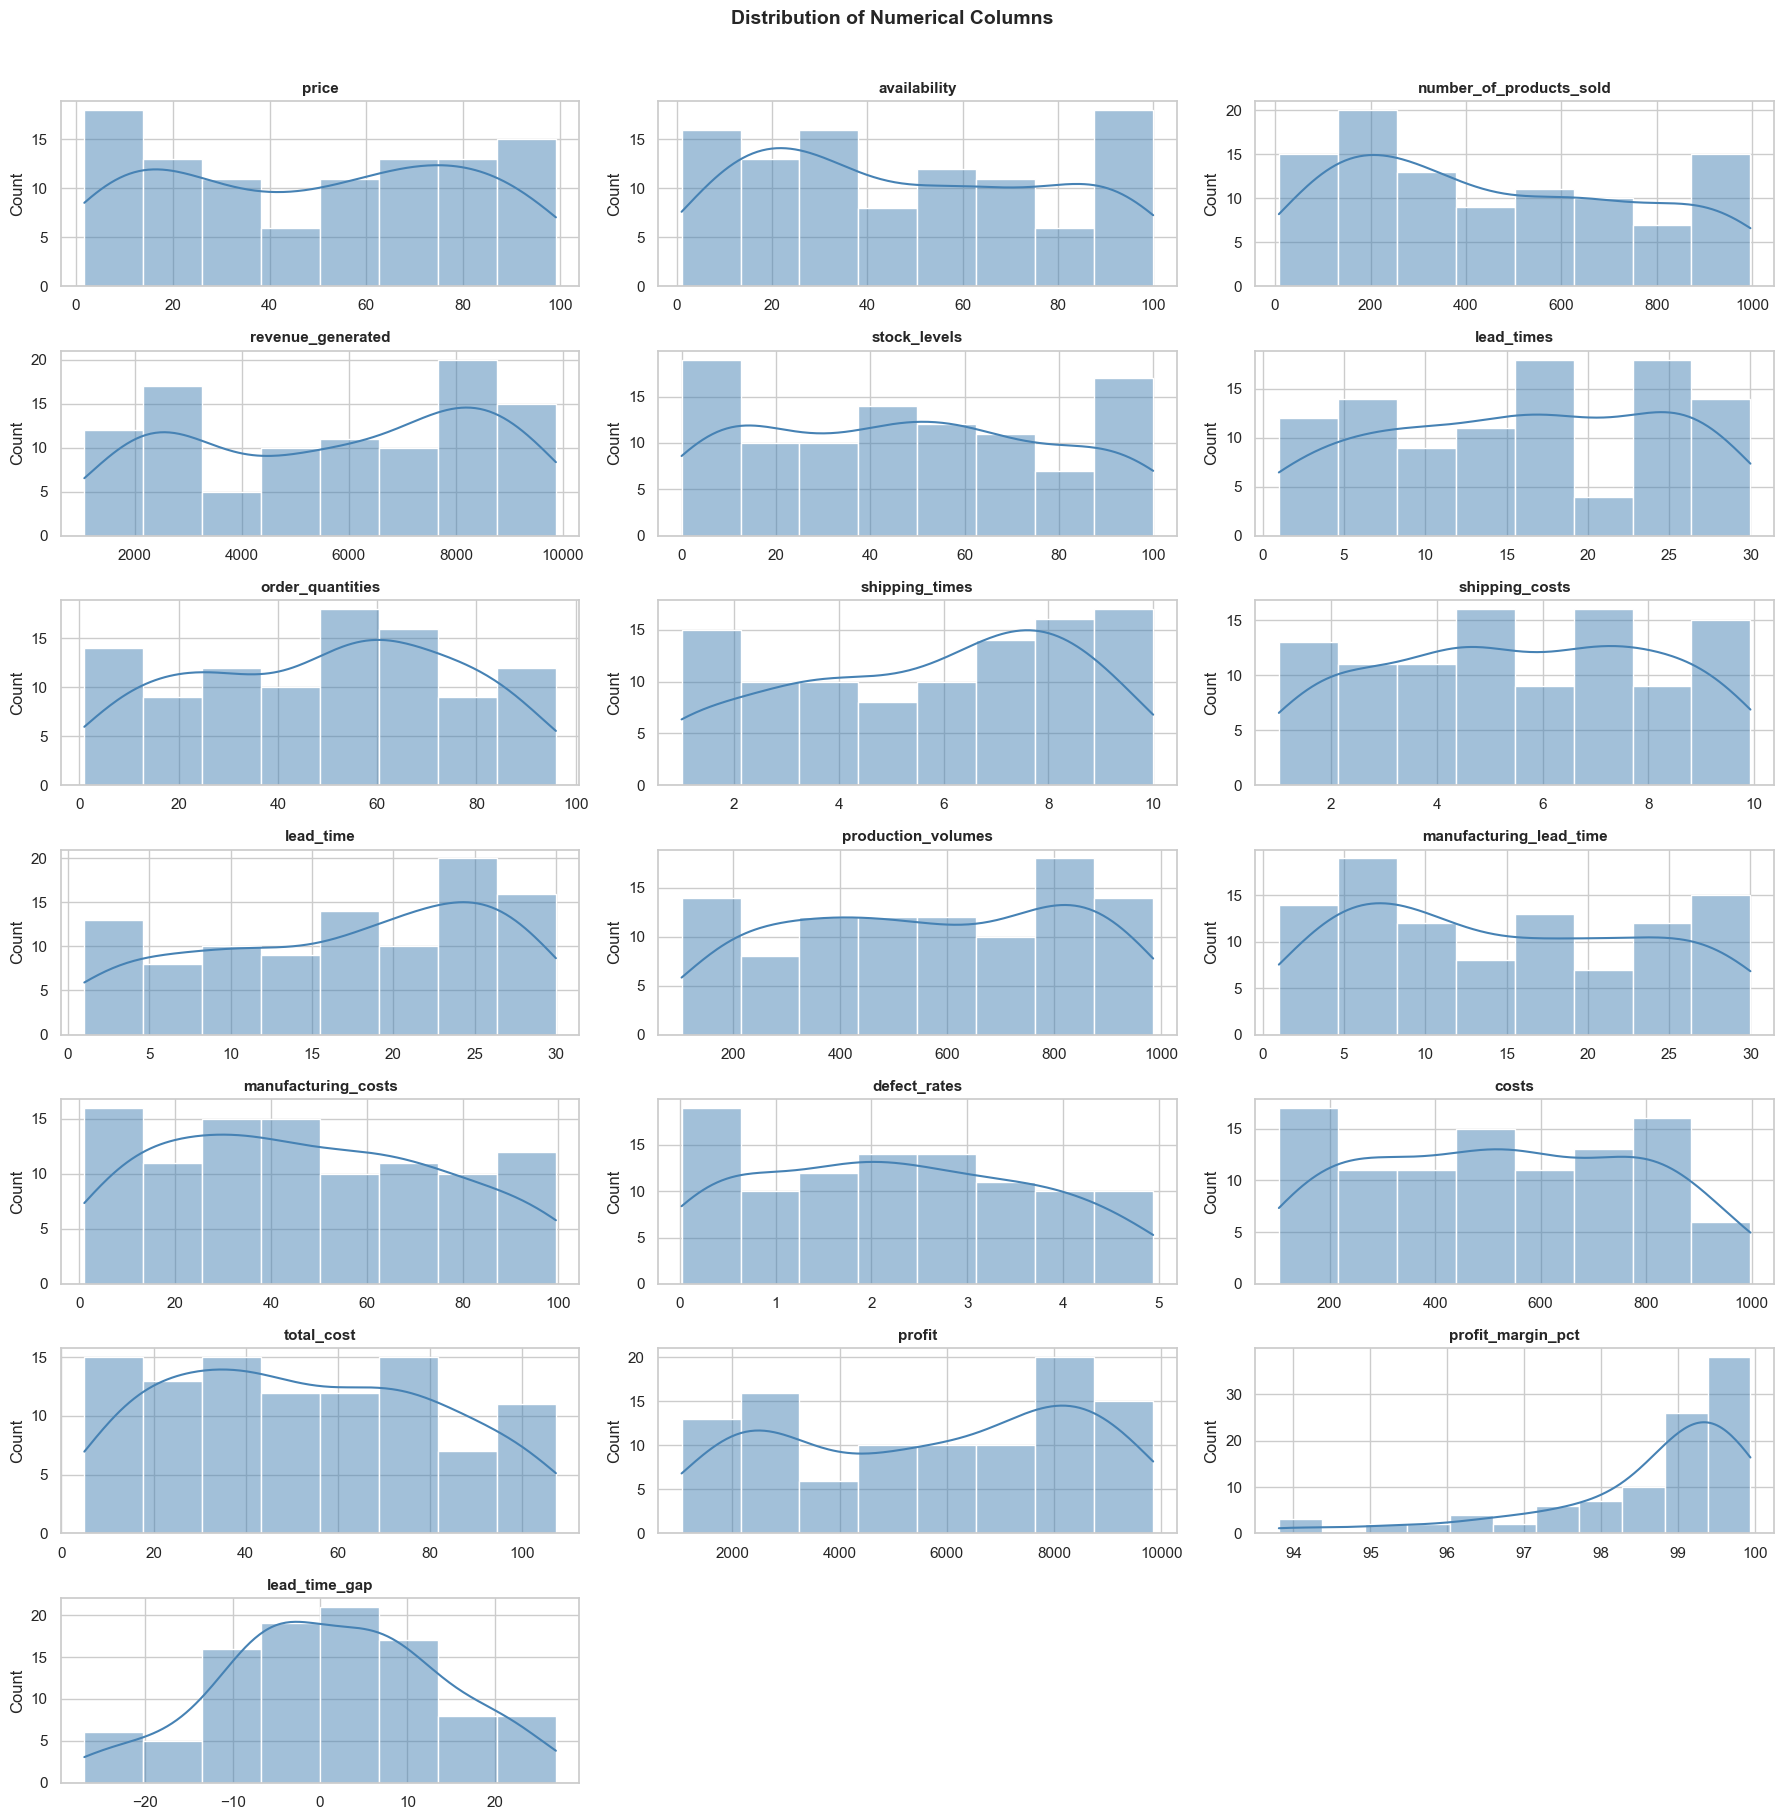

In [22]:
num_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(nrows=(len(num_cols) + 2) // 3, ncols=3, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Columns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Numerical Data Distribution**

The numerical variables show several interesting patterns that help us better understand the supply chain performance.

Product prices are distributed quite evenly across different price ranges, indicating a diverse product portfolio without a dominant pricing segment. The number of products sold is right-skewed, meaning most products have relatively low sales while only a few become top sellers. Revenue is also fairly spread across the dataset, reflecting varying sales performance among products.

Lead times vary considerably, with no clear concentration around a specific value. This inconsistency may indicate opportunities to improve supply chain stability and planning. Defect rates mostly fall between 0–5%, with noticeable peaks at both low and high values, suggesting differences in quality performance across suppliers or product groups.

Profit margins are highly concentrated around **94–100%**, which is unusually high and may be influenced by the way costs are recorded rather than actual business performance. Finally, the **Lead Time Gap** contains several negative values, meaning manufacturing time exceeds the recorded total lead time. Since this is logically impossible, these records likely represent data quality issues that should be considered during further analysis.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2548\1045234789.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[i], palette='muted')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_2548\1045234789.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[i], palette='muted')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_2548\1045234789.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[i], palette='muted')
C:\Users\ASUS\AppData\Local\Temp\i

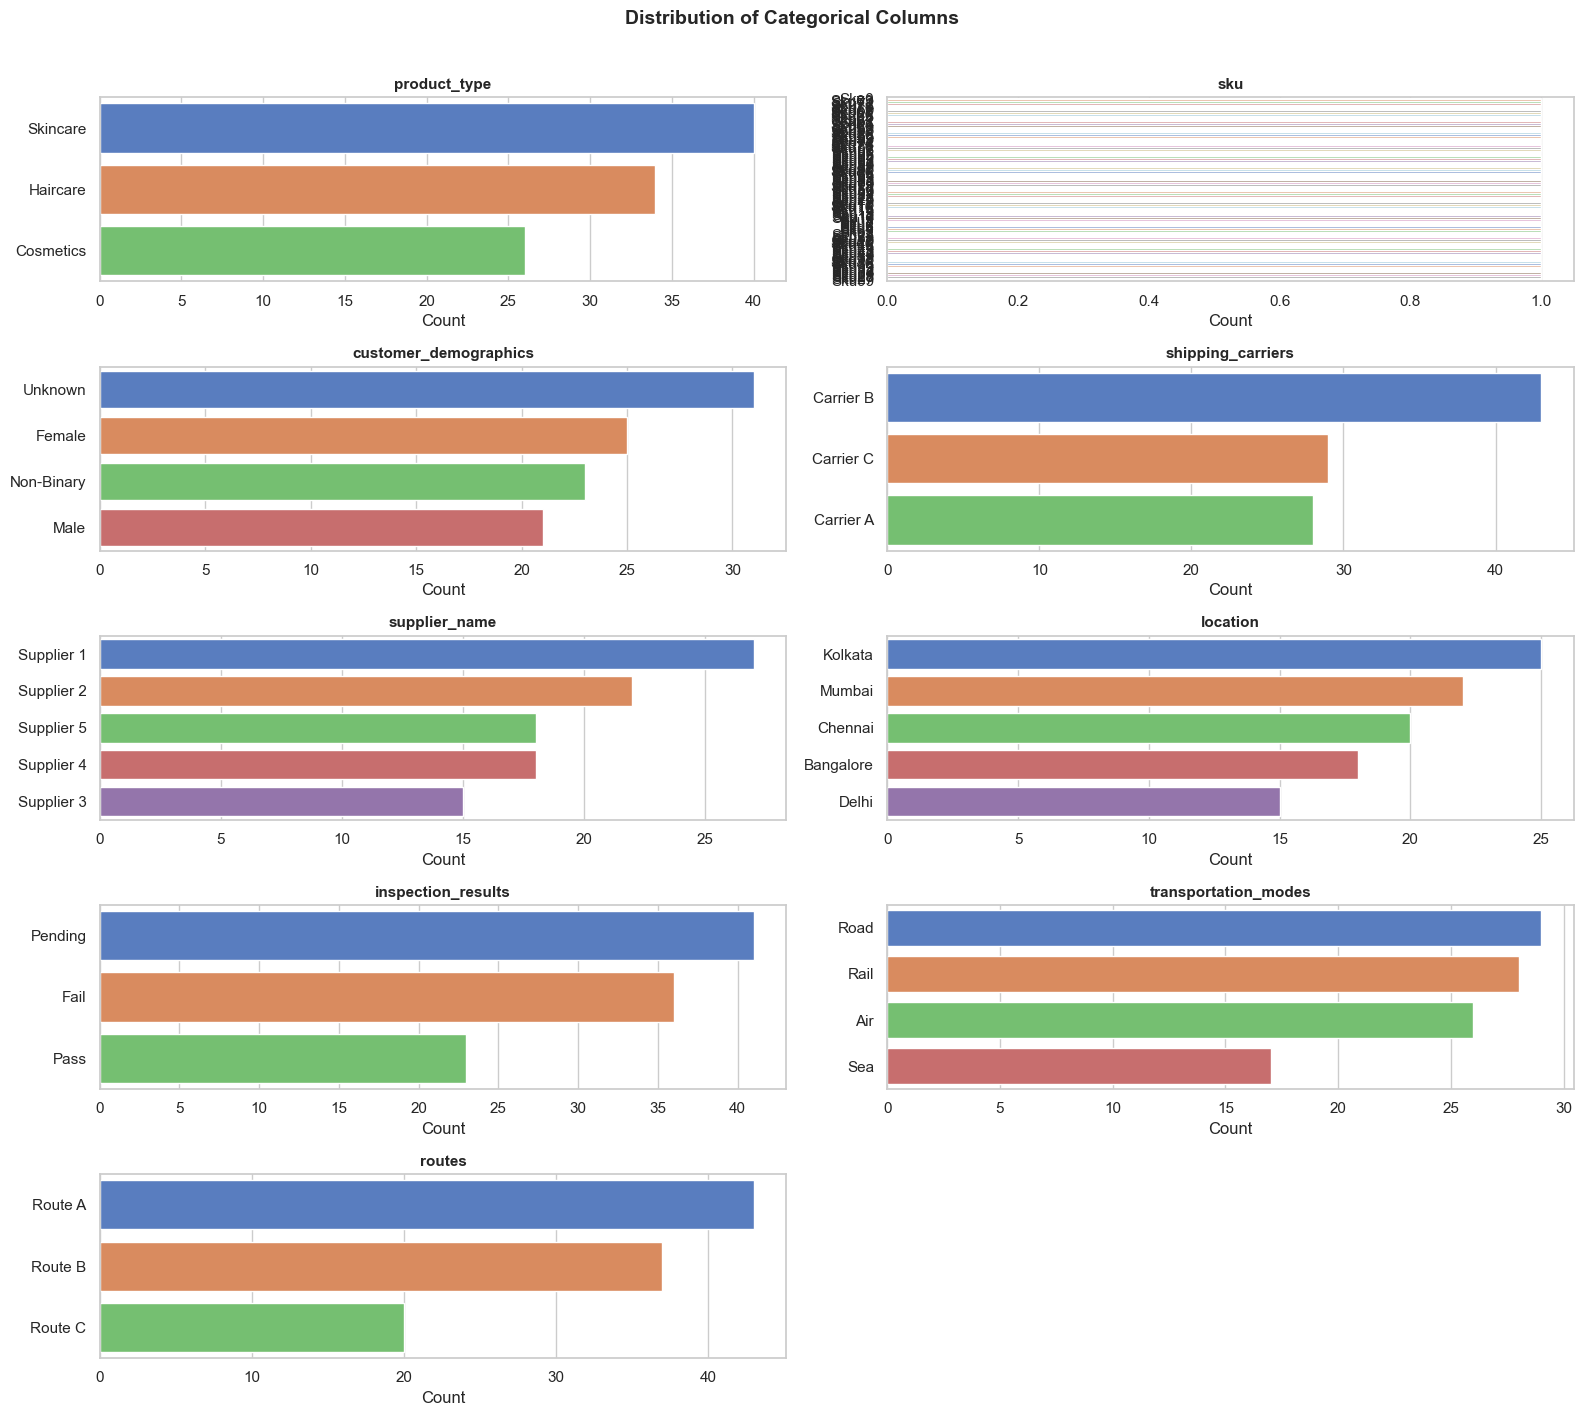

In [23]:
fig, axes = plt.subplots(nrows=(len(cat_cols) + 1) // 2, ncols=2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i], palette='muted')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Categorical Columns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Categorical Data Overview**

Overall, the product categories are fairly balanced, although **Cosmetics** has the smallest number of products. Customer demographic data reveals a notable data quality issue, as around one-third of the records are labeled as **Unknown**, indicating missing customer segment information.

From the supplier perspective, **Supplier 1** contributes the largest number of products, while **Supplier 3** supplies the fewest. This raises an interesting question about whether higher product volume also translates into better supplier performance, which will be explored later.

Products are sourced from five cities across India, with **Kolkata** appearing most frequently and **Delhi** the least. Shipping carriers are also distributed relatively evenly, with **Carrier B** handling slightly more shipments. In terms of transportation, **Road** and **Rail** are the most common modes, while **Sea** is used the least. Similarly, **Route A** and **Route B** dominate the shipping routes.

The most critical finding is the **Inspection Results**. Only about **24%** of products have passed quality inspection, while the remaining **76%** either failed or are still pending inspection. This suggests a potential quality control issue that will be investigated further in the Quality & Defect Analysis section.


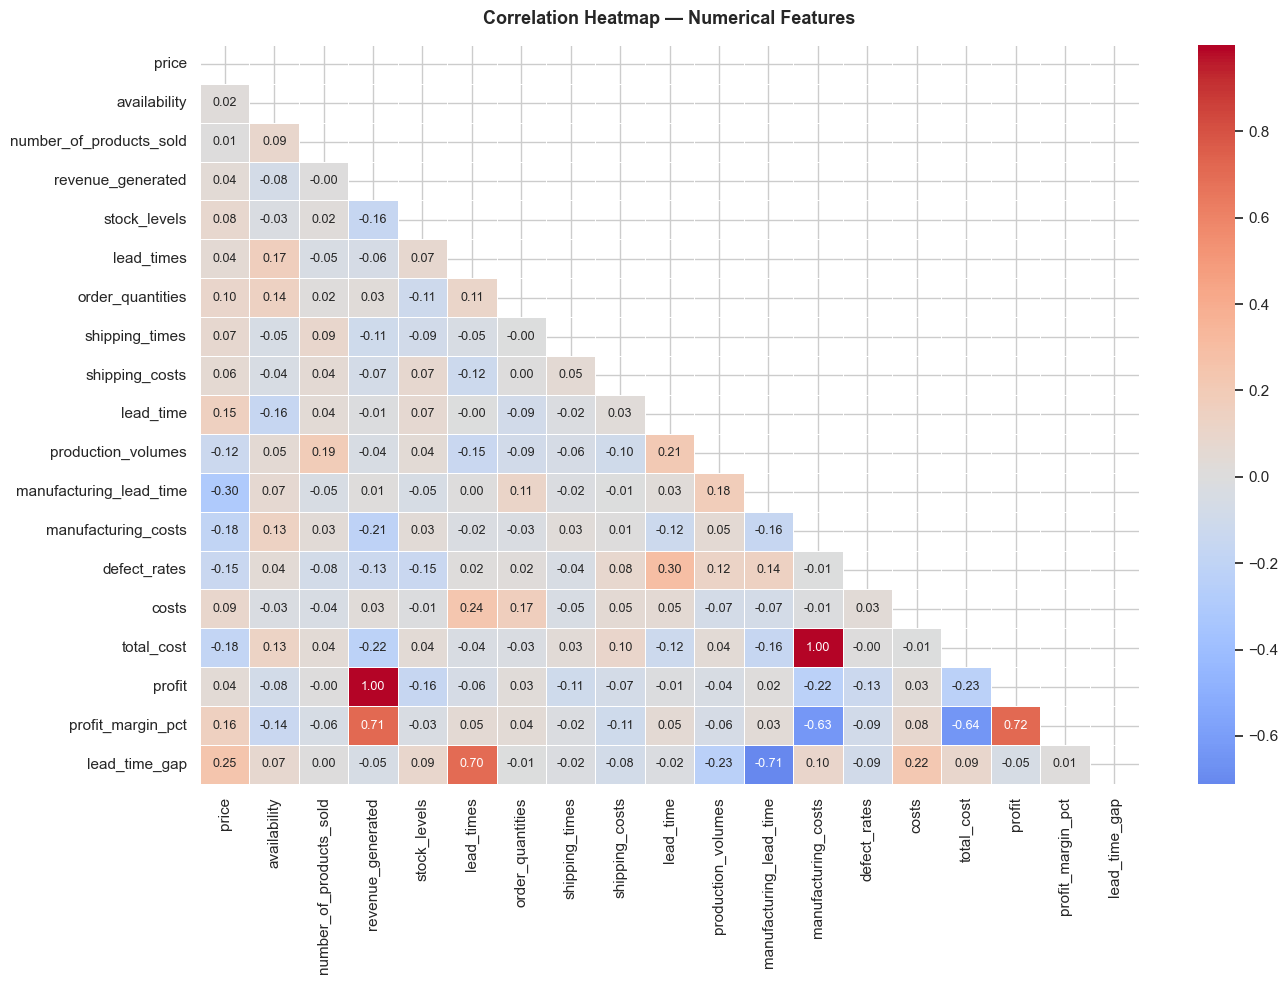

In [24]:
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include='number').corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 9})

plt.title('Correlation Heatmap — Numerical Features',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Correlation Analysis**

The correlation analysis shows that most numerical variables have weak relationships with one another, indicating that supply chain performance is influenced by multiple factors rather than a single dominant variable.

Several strong correlations stand out. **Profit** is perfectly correlated with **Revenue Generated**, as expected since profit is derived from revenue. Likewise, **Total Cost** is almost entirely driven by **Manufacturing Costs**, suggesting that manufacturing is the primary contributor to overall costs, while shipping costs have a relatively small impact.

The analysis also highlights an issue with the **Lead Time Gap**. It is positively correlated with **Lead Time** but negatively correlated with **Manufacturing Lead Time**, reinforcing the earlier observation that some records contain inconsistent lead time values and may represent data quality problems.

In terms of profitability, higher **Total Cost** and **Manufacturing Costs** are associated with lower **Profit Margin**, confirming that manufacturing efficiency plays a major role in maintaining profitability. Meanwhile, suppliers with longer lead times tend to have slightly higher defect rates, suggesting a possible link between delivery delays and product quality that deserves further investigation.

Overall, these results indicate that supply chain performance is shaped by a combination of cost, quality, supplier performance, and logistics, making a comprehensive, multi-angle analysis essential.


#### 3.2 Supplier Performance Analysis

Suppliers are the starting point of everything — if they're slow, costly, or producing defective goods, the impact ripples across the entire operation. In this session, we evaluate all five suppliers across four dimensions: defect rate, lead time, manufacturing cost, and inspection results.

**Supplier Overview**

In [25]:
#Supplier Overview
supplier_summary = df.groupby('supplier_name').agg(
    total_products    = ('sku', 'count'),
    avg_lead_time     = ('lead_time', 'mean'),
    avg_defect_rate   = ('defect_rates', 'mean'),
    avg_mfg_cost      = ('manufacturing_costs', 'mean'),
    avg_mfg_lead_time = ('manufacturing_lead_time', 'mean'),
    total_revenue     = ('revenue_generated', 'sum'),
    avg_production_vol= ('production_volumes', 'mean')
).round(2).sort_values('avg_defect_rate', ascending=False)

print("\n Supplier Summary Table:\n")
display(supplier_summary)


 Supplier Summary Table:



,total_products,avg_lead_time,avg_defect_rate,avg_mfg_cost,avg_mfg_lead_time,total_revenue,avg_production_vol
supplier_name,,,,,,,
Supplier 5,18,18.06,2.67,44.77,16.33,110343.46,521.17
Supplier 3,15,20.13,2.47,43.63,14.93,97795.98,533.13
Supplier 2,22,18.55,2.36,41.62,15.59,125467.42,641.14
Supplier 4,18,15.22,2.34,62.71,15.33,86468.96,653.11
Supplier 1,27,14.78,1.80,45.25,12.59,157529.00,501.67



At a glance, the five suppliers are not created equal. Supplier 1 handles the 
most products (27 SKUs) and generates the highest revenue at $157,529 — while 
also maintaining the fastest lead time (14.78 days) and the lowest defect rate 
(1.80%). On the other end, Supplier 3 is the slowest (20.13 days lead time) 
with the lowest revenue contribution ($97,795), and Supplier 4 stands out for 
an entirely different reason: the highest manufacturing cost at $62.71 per unit 
— nearly 32% above the group average of $47.60.

**Defect Rate — Who's Producing the Most Faulty Products?**


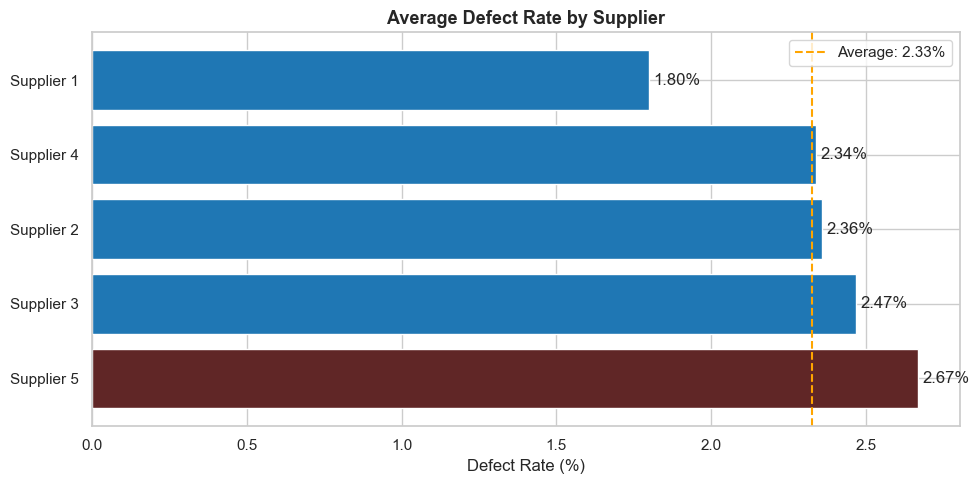

In [26]:
#Defect Rate per Supplier
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#602626" if x == supplier_summary['avg_defect_rate'].max()
          else '#1f77b4' for x in supplier_summary['avg_defect_rate']]

bars = ax.barh(supplier_summary.index, supplier_summary['avg_defect_rate'], color=colors)
ax.axvline(supplier_summary['avg_defect_rate'].mean(), color='orange',
           linestyle='--', linewidth=1.5, label=f"Average: {supplier_summary['avg_defect_rate'].mean():.2f}%")

ax.bar_label(bars, fmt='%.2f%%', padding=3)
ax.set_title('Average Defect Rate by Supplier', fontsize=13, fontweight='bold')
ax.set_xlabel('Defect Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

The average defect rate across all suppliers is **2.33%**, but their performance varies noticeably. **Supplier 1** delivers the best quality with a defect rate of just **1.80%**, making it the only supplier performing better than the overall average.

On the other hand, **Supplier 5** records the highest defect rate at **2.67%**, around **48% higher** than Supplier 1. Meanwhile, **Supplier 2**, **Supplier 3**, and **Supplier 4** all have defect rates slightly above the average, ranging from **2.34% to 2.47%**.

Overall, **four out of five suppliers** are performing below the desired quality standard. This suggests that quality issues are not limited to a single supplier but are widespread across the supplier network, making supplier quality improvement an important priority for Beautica Store.


**Lead Time — Where Are the Delays Coming From?**

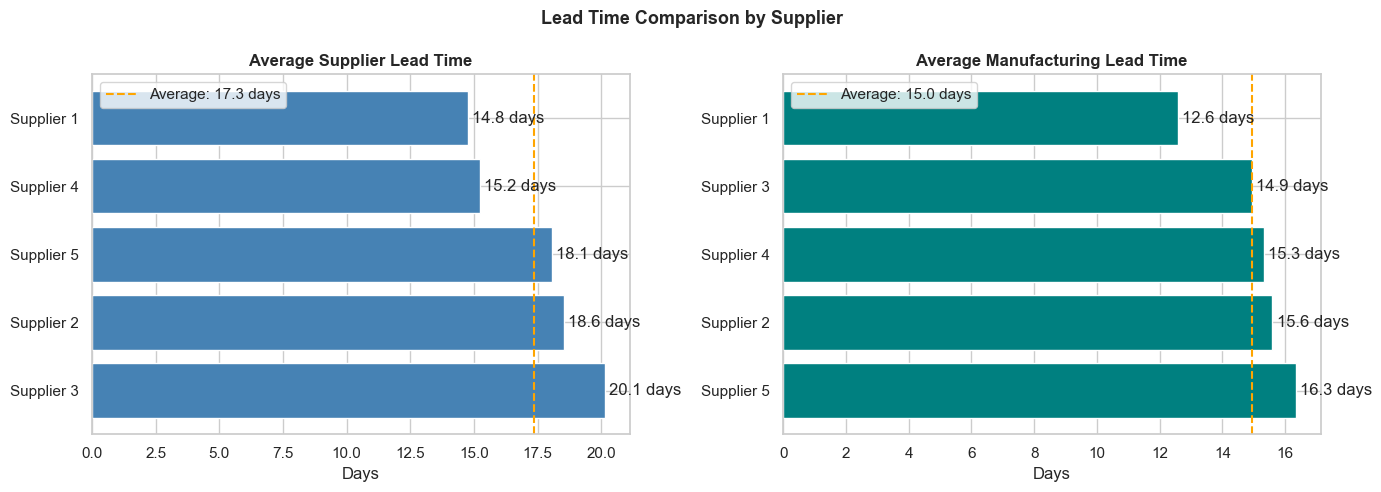

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Supplier Lead Time
sup_lt = supplier_summary['avg_lead_time'].sort_values(ascending=False)
bars1 = axes[0].barh(sup_lt.index, sup_lt.values, color='steelblue')
axes[0].axvline(sup_lt.mean(), color='orange', linestyle='--',
                linewidth=1.5, label=f"Average: {sup_lt.mean():.1f} days")
axes[0].bar_label(bars1, fmt='%.1f days', padding=3)
axes[0].set_title('Average Supplier Lead Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Days')
axes[0].legend()

# Manufacturing Lead Time
mfg_lt = supplier_summary['avg_mfg_lead_time'].sort_values(ascending=False)
bars2 = axes[1].barh(mfg_lt.index, mfg_lt.values, color='teal')
axes[1].axvline(mfg_lt.mean(), color='orange', linestyle='--',
                linewidth=1.5, label=f"Average: {mfg_lt.mean():.1f} days")
axes[1].bar_label(bars2, fmt='%.1f days', padding=3)
axes[1].set_title('Average Manufacturing Lead Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Days')
axes[1].legend()

plt.suptitle('Lead Time Comparison by Supplier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The average supplier lead time is **17.3 days**. **Supplier 1** and **Supplier 4** perform the best, delivering products in **14.8** and **15.2 days**, respectively. In contrast, **Supplier 3** has the longest lead time at **20.1 days**, taking more than **5 days longer** than Supplier 1.

A closer comparison between supplier lead time and manufacturing lead time reveals an interesting insight. Although **Supplier 3** only spends **14.9 days** on manufacturing, its total lead time reaches **20.1 days**. This indicates that the delay is likely occurring after production, such as during logistics, administrative processes, or product handover, rather than in the manufacturing stage itself.

Meanwhile, **Supplier 5** has the longest manufacturing lead time at **16.3 days**. Combined with its relatively high defect rate, this may suggest that inefficiencies in the production process are contributing to both longer manufacturing times and lower product quality.


**Manufacturing Cost — Expensive Doesn't Always Mean Better**

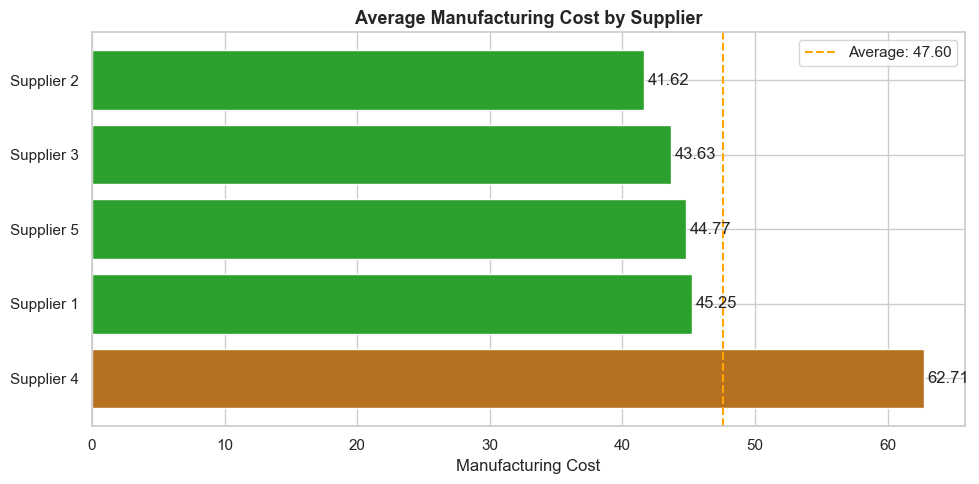

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

mfg_cost = supplier_summary['avg_mfg_cost'].sort_values(ascending=False)
colors = ["#b57020" if x == mfg_cost.max() else '#2ca02c' for x in mfg_cost]

bars = ax.barh(mfg_cost.index, mfg_cost.values, color=colors)
ax.axvline(mfg_cost.mean(), color='orange', linestyle='--',
           linewidth=1.5, label=f"Average: {mfg_cost.mean():.2f}")
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_title('Average Manufacturing Cost by Supplier', fontsize=13, fontweight='bold')
ax.set_xlabel('Manufacturing Cost')
ax.legend()
plt.tight_layout()
plt.show()

**Supplier 4** stands out as the most expensive supplier, with an average manufacturing cost of **$62.71 per unit**. This is considerably higher than the other suppliers, with **Supplier 1** coming in second at **$45.25 per unit**.

Despite these higher production costs, Supplier 4 generates only **$86,468** in revenue, making it the **second-lowest revenue contributor** among all suppliers. This suggests that the additional manufacturing cost is not translating into better business performance. Instead, Beautica Store is paying a significant cost premium without receiving proportional returns, making Supplier 4 a key area for further performance review.


**Inspection Results — A Closer Look at Product Quality**

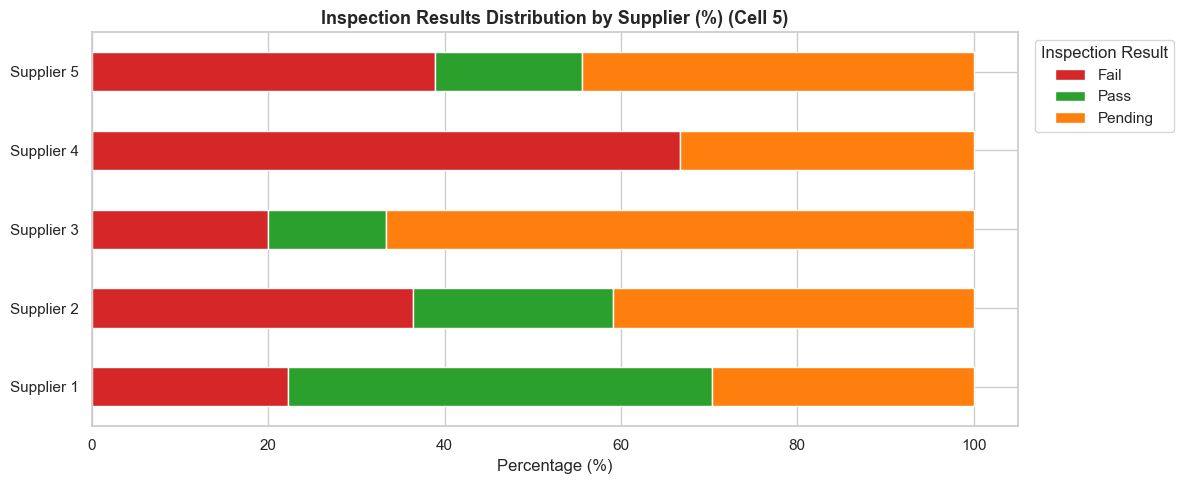

In [29]:
inspection_by_supplier = df.groupby(['supplier_name', 'inspection_results'])\
                           .size().unstack(fill_value=0)

inspection_pct = inspection_by_supplier.div(inspection_by_supplier.sum(axis=1), axis=0) * 100

inspection_pct.plot(kind='barh', stacked=True, figsize=(12, 5),
                    color={'Pass': '#2ca02c', 'Fail': '#d62728', 'Pending': '#ff7f0e'})

plt.title('Inspection Results Distribution by Supplier (%) (Cell 5)', fontsize=13, fontweight='bold')
plt.xlabel('Percentage (%)')
plt.ylabel('')
plt.legend(title='Inspection Result', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()



The inspection results reveal clear differences in quality performance across suppliers.

**Supplier 1** delivers the strongest performance, with the highest pass rate at around **47%** and one of the lowest fail rates, making it the most reliable supplier in terms of product quality.

In contrast, **Supplier 4** records the highest fail rate at approximately **67%**. Considering it also has the highest manufacturing cost, this supplier appears to provide the weakest overall value and should be a priority for further evaluation.

**Supplier 5** also shows quality concerns, with a fail rate of around **38%** and a relatively low pass rate of only **17%**, which aligns with its high defect rate. Meanwhile, **Supplier 3** has most of its products still marked as **Pending** (around **67%**), creating uncertainty because a large portion of its products have not yet completed the inspection process.

**Supplier 2** performs somewhere in the middle, with pass and fail rates that are relatively balanced, although there is still considerable room for improvement.


**Supplier Quadrant — Visualizing the Risk**

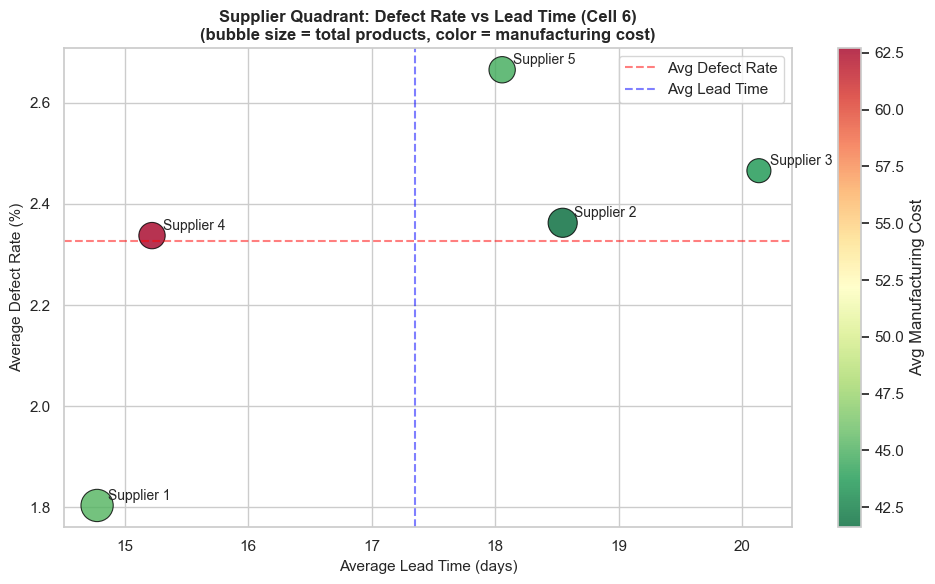

In [30]:
supplier_scatter = df.groupby('supplier_name').agg(
    avg_defect_rate=('defect_rates', 'mean'),
    avg_lead_time=('lead_time', 'mean'),
    avg_mfg_cost=('manufacturing_costs', 'mean'),
    total_products=('sku', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    supplier_scatter['avg_lead_time'],
    supplier_scatter['avg_defect_rate'],
    s=supplier_scatter['total_products'] * 20,
    c=supplier_scatter['avg_mfg_cost'],
    cmap='RdYlGn_r',
    alpha=0.8,
    edgecolors='black',
    linewidth=0.8
)

for _, row in supplier_scatter.iterrows():
    ax.annotate(row['supplier_name'],
                (row['avg_lead_time'], row['avg_defect_rate']),
                textcoords='offset points', xytext=(8, 4), fontsize=10)

plt.colorbar(scatter, label='Avg Manufacturing Cost')
ax.axhline(supplier_scatter['avg_defect_rate'].mean(), color='red',
           linestyle='--', alpha=0.5, label='Avg Defect Rate')
ax.axvline(supplier_scatter['avg_lead_time'].mean(), color='blue',
           linestyle='--', alpha=0.5, label='Avg Lead Time')

ax.set_xlabel('Average Lead Time (days)', fontsize=11)
ax.set_ylabel('Average Defect Rate (%)', fontsize=11)
ax.set_title('Supplier Quadrant: Defect Rate vs Lead Time (Cell 6)\n(bubble size = total products, color = manufacturing cost)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

The scatter plot positions each supplier across two key risk dimensions: 
lead time (x-axis) and defect rate (y-axis). The ideal position is the 
bottom-left quadrant — fast and clean.

Only **Supplier 1** sits comfortably in that zone. The remaining four 
suppliers all fall in higher-risk positions:

- **Supplier 5 and Supplier 3** sit in the top-right — slow lead times and 
  high defect rates. These are the most operationally risky suppliers.
- **Supplier 2** is slightly above average on both dimensions, sitting on 
  the border.
- **Supplier 4** is fast but expensive and sits above the average defect 
  line — its red color on the chart signals the highest manufacturing cost, 
  making it a costly underperformer.


**Supplier Performance Ranking**

🏆 Supplier Performance Ranking:



,performance_score,rank,status
supplier_name,,,
Supplier 1,94.26,1,🟢 Good
Supplier 2,55.05,2,🟡 Average
Supplier 4,43.24,3,🟡 Average
Supplier 5,41.25,4,🟡 Average
Supplier 3,37.82,5,🔴 Poor


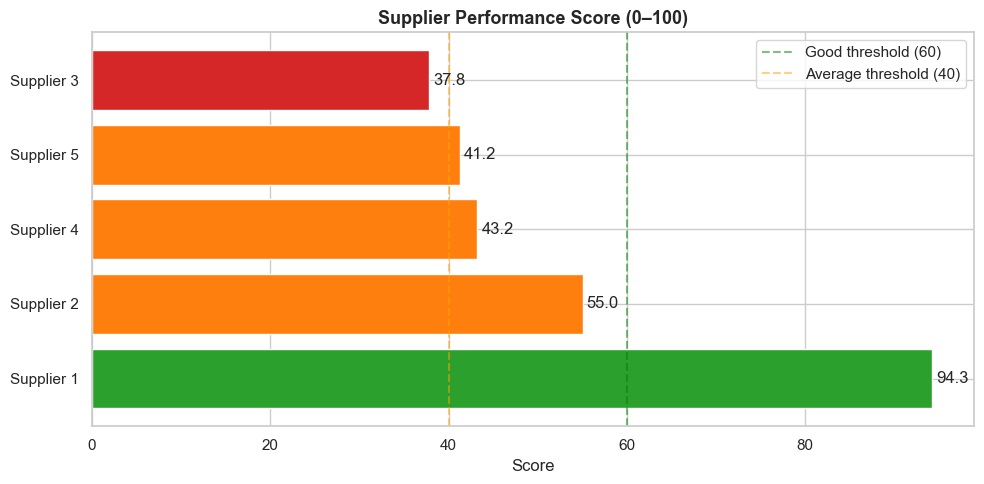

In [31]:
# Normalize metrics (lower is better for defect, lead time, cost)
from sklearn.preprocessing import MinMaxScaler

perf_df = supplier_summary[['avg_defect_rate', 'avg_lead_time', 'avg_mfg_cost']].copy()
scaler = MinMaxScaler()
scaled = scaler.fit_transform(perf_df)
scaled_df = pd.DataFrame(scaled, index=perf_df.index,
                         columns=['defect_score', 'lead_time_score', 'cost_score'])

# Performance score: lower normalized value = better performance
scaled_df['performance_score'] = (1 - scaled_df.mean(axis=1)).round(4) * 100

ranking = scaled_df[['performance_score']].sort_values('performance_score', ascending=False)
ranking['rank'] = range(1, len(ranking) + 1)
ranking['status'] = ranking['performance_score'].apply(
    lambda x: '🟢 Good' if x >= 60 else ('🟡 Average' if x >= 40 else '🔴 Poor')
)

print("🏆 Supplier Performance Ranking:\n")
display(ranking)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ca02c' if s >= 60 else '#ff7f0e' if s >= 40 else '#d62728'
          for s in ranking['performance_score']]
bars = ax.barh(ranking.index, ranking['performance_score'], color=colors)
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.axvline(60, color='green', linestyle='--', alpha=0.5, label='Good threshold (60)')
ax.axvline(40, color='orange', linestyle='--', alpha=0.5, label='Average threshold (40)')
ax.set_title('Supplier Performance Score (0–100)', fontsize=13, fontweight='bold')
ax.set_xlabel('Score')
ax.legend()
plt.tight_layout()
plt.show()


To summarize performance across all dimensions, we built a composite 
performance score (0–100) based on normalized defect rate, lead time, 
and manufacturing cost — where higher is better.

| Rank | Supplier | Score | Status |
|---|---|---|---|
| 1 | Supplier 1 | 94.3 | 🟢 Good |
| 2 | Supplier 2 | 55.0 | 🟡 Average |
| 3 | Supplier 4 | 43.2 | 🟡 Average |
| 4 | Supplier 5 | 41.2 | 🟡 Average |
| 5 | Supplier 3 | 37.8 | 🔴 Poor |

The gap between Supplier 1 (94.3) and everyone else is striking. 
Supplier 1 isn't just the best — it's in a completely different league. 
Supplier 3 is the only one formally rated Poor, while Supplier 4 and 5 
are dangerously close to that threshold.

### 💡 Key Takeaways — Session 2

* **Supplier 1 sets the benchmark**, consistently delivering the best overall performance with the lowest defect rate, fast lead times, strong revenue, and the highest inspection pass rate.

* **Supplier 4 is the least cost-efficient supplier.** Despite having the highest manufacturing cost, its revenue and quality performance remain relatively weak, making it a priority for cost review or supplier evaluation.

* **Supplier 5 shows signs of production inefficiency**, combining a high defect rate with the longest manufacturing lead time. A deeper review of its production process is recommended.

* **Supplier 3's main bottleneck is likely outside manufacturing.** Although its production time is reasonable, its overall supplier lead time is the longest, suggesting delays in logistics, administration, or product handover.

* **Quality improvement should be a network-wide initiative.** Since four out of five suppliers have defect rates above the overall average, Beautica Store should focus on strengthening quality management across its entire supplier base rather than targeting only one supplier.


#### 3.3 Delivery Delay Patterns

With supplier performance mapped out, we now shift focus to the next link in the chain: how products actually get delivered. Delivery delays are one of the most visible pain points in any supply chain — customers feel them directly, and they quietly erode trust and revenue over time.

In this session, we examine shipping performance across three dimensions: 
carriers, transportation modes, and routes — and identify which combinations 
are causing the most delays.


**Shipping Overview**

In [32]:
#Shipping Overview
shipping_summary = df.groupby('shipping_carriers').agg(
    total_shipments   = ('sku', 'count'),
    avg_shipping_time = ('shipping_times', 'mean'),
    avg_shipping_cost = ('shipping_costs', 'mean'),
    avg_lead_time     = ('lead_times', 'mean'),
    total_revenue     = ('revenue_generated', 'sum')
).round(2).sort_values('avg_shipping_time', ascending=False)

display(shipping_summary)

,total_shipments,avg_shipping_time,avg_shipping_cost,avg_lead_time,total_revenue
shipping_carriers,,,,,
Carrier A,28,6.14,5.55,14.96,142629.99
Carrier C,29,6.03,5.60,17.00,184880.18
Carrier B,43,5.30,5.51,15.91,250094.65


**Shipping Time per Carrier**

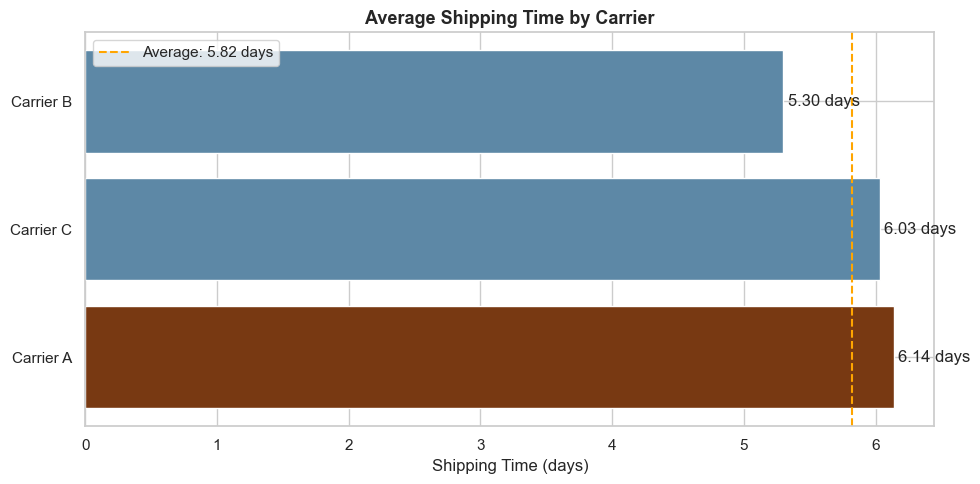

In [33]:
#Graph Shipping time for each Carrier
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#783912" if x == shipping_summary['avg_shipping_time'].max()
          else "#5d88a6" for x in shipping_summary['avg_shipping_time']]

bars = ax.barh(shipping_summary.index, 
               shipping_summary['avg_shipping_time'], color=colors)
ax.axvline(shipping_summary['avg_shipping_time'].mean(), color='orange',
           linestyle='--', linewidth=1.5,
           label=f"Average: {shipping_summary['avg_shipping_time'].mean():.2f} days")

ax.bar_label(bars, fmt='%.2f days', padding=3)
ax.set_title('Average Shipping Time by Carrier', fontsize=13, fontweight='bold')
ax.set_xlabel('Shipping Time (days)')
ax.legend()
plt.tight_layout()
plt.show()

The comparison between shipping carriers reveals noticeable differences in performance.

* **Carrier B** is the strongest overall performer. It handles the highest number of shipments, delivers the fastest average shipping time (**5.30 days**), has the **lowest shipping cost**, and generates the **highest revenue**, making it the most efficient carrier in the network.

* **Carrier C** performs at a moderate level. It handles fewer shipments than Carrier B, has a slightly longer delivery time, and records the **highest shipping cost** among the three carriers.

* **Carrier A** shows the weakest performance. It handles the fewest shipments, has the **slowest average delivery time** (**6.14 days**), and contributes the **lowest revenue**, despite having shipping costs that are similar to the other carriers.

* Although the delivery time difference between the fastest and slowest carrier is only **0.84 days per shipment**, this gap can accumulate into significant delays when scaled across a large number of shipments throughout the year.


**Shipping Time per Transportation Mode**

📋 Transportation Mode Summary:



,total_shipments,avg_shipping_time,avg_shipping_cost,avg_lead_time
transportation_modes,,,,
Sea,17,7.12,4.97,12.18
Rail,28,6.57,5.47,14.89
Air,26,5.12,6.02,18.27
Road,29,4.72,5.54,17.14


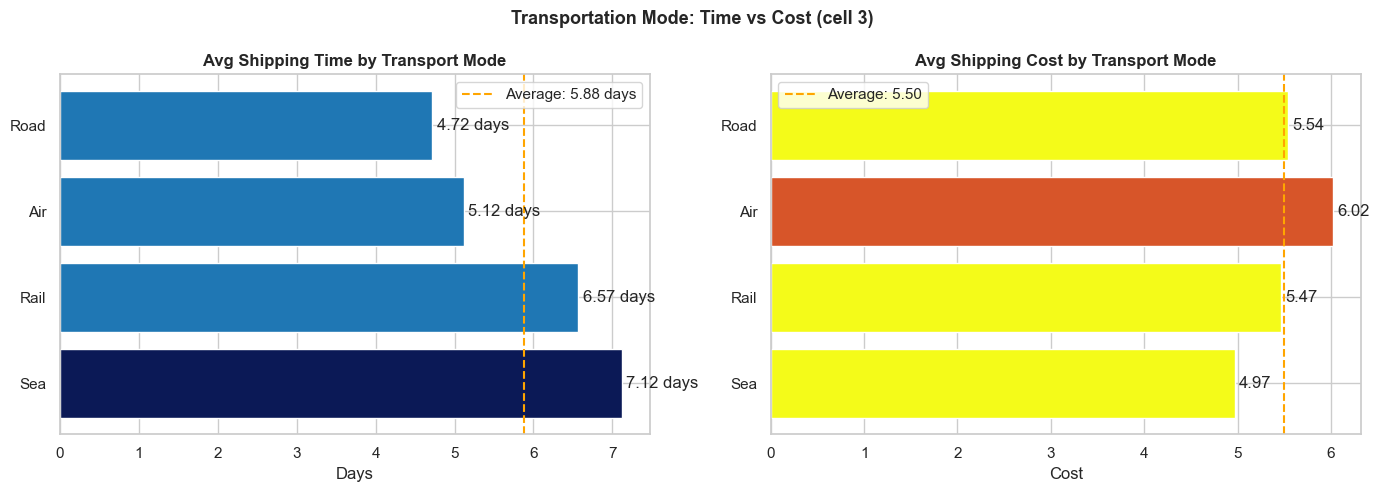

In [34]:
#shipping per transport mode
mode_summary = df.groupby('transportation_modes').agg(
    total_shipments   = ('sku', 'count'),
    avg_shipping_time = ('shipping_times', 'mean'),
    avg_shipping_cost = ('shipping_costs', 'mean'),
    avg_lead_time     = ('lead_times', 'mean')
).round(2).sort_values('avg_shipping_time', ascending=False)

print("📋 Transportation Mode Summary:\n")
display(mode_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Shipping time per mode
colors_mode = ["#0b1956" if x == mode_summary['avg_shipping_time'].max()
               else '#1f77b4' for x in mode_summary['avg_shipping_time']]
bars1 = axes[0].barh(mode_summary.index, 
                     mode_summary['avg_shipping_time'], color=colors_mode)
axes[0].axvline(mode_summary['avg_shipping_time'].mean(), color='orange',
                linestyle='--', linewidth=1.5,
                label=f"Average: {mode_summary['avg_shipping_time'].mean():.2f} days")
axes[0].bar_label(bars1, fmt='%.2f days', padding=3)
axes[0].set_title('Avg Shipping Time by Transport Mode', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Days')
axes[0].legend()

# Shipping cost per mode
colors_cost = ["#d75529" if x == mode_summary['avg_shipping_cost'].max()
               else "#f4fb19" for x in mode_summary['avg_shipping_cost']]
bars2 = axes[1].barh(mode_summary.index, 
                     mode_summary['avg_shipping_cost'], color=colors_cost)
axes[1].axvline(mode_summary['avg_shipping_cost'].mean(), color='orange',
                linestyle='--', linewidth=1.5,
                label=f"Average: {mode_summary['avg_shipping_cost'].mean():.2f}")
axes[1].bar_label(bars2, fmt='%.2f', padding=3)
axes[1].set_title('Avg Shipping Cost by Transport Mode', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cost')
axes[1].legend()

plt.suptitle('Transportation Mode: Time vs Cost (cell 3)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Each transportation mode offers a different balance between delivery speed and shipping cost.

* **Road** is the most efficient option, delivering the fastest average shipping time (**4.72 days**) while also costing less than **Air**. This makes it the best overall choice for both speed and cost efficiency.

* **Air** is the **most expensive** transportation mode, yet it is **slower than Road**. This suggests that some shipments may be using Air without gaining a meaningful speed advantage, creating an opportunity to optimize transportation costs.

* **Sea** is the **slowest** mode of transportation but also the **least expensive**. It is best suited for non-urgent or high-volume shipments where minimizing shipping costs is more important than fast delivery.

* **Rail** sits between the other options, offering moderate shipping times and costs. However, it does not clearly outperform the other modes in either speed or cost, making its value proposition less obvious.

**Shipping Time per Route**

📋 Route Summary:



,total_shipments,avg_shipping_time,avg_shipping_cost,avg_lead_time
routes,,,,
Route A,43,6.02,5.38,14.70
Route B,37,5.70,5.55,17.22
Route C,20,5.25,5.90,16.35


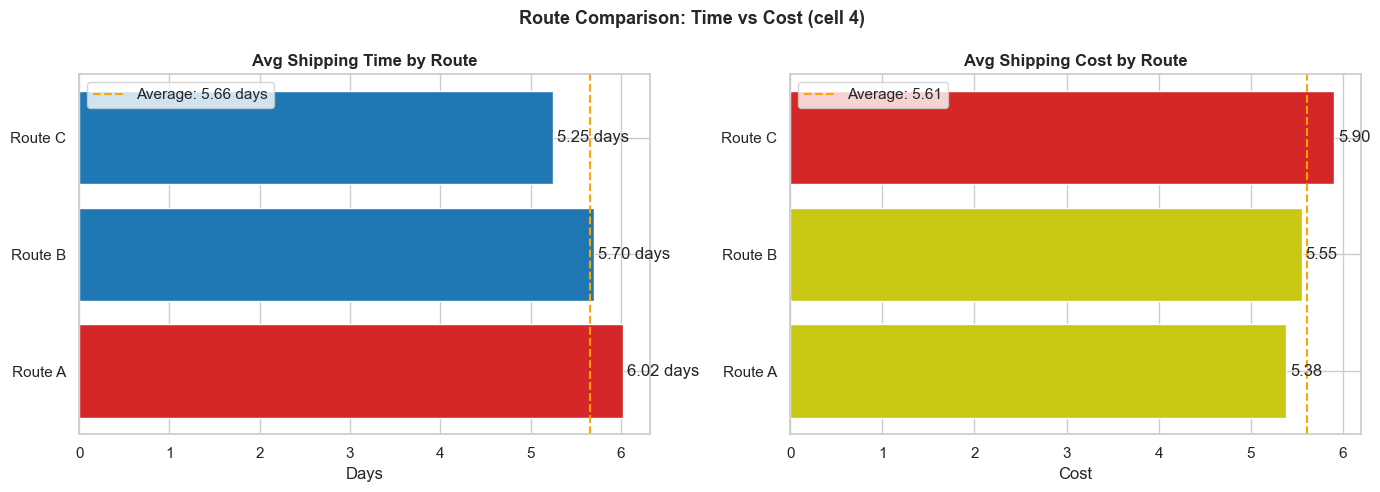

In [35]:
route_summary = df.groupby('routes').agg(
    total_shipments   = ('sku', 'count'),
    avg_shipping_time = ('shipping_times', 'mean'),
    avg_shipping_cost = ('shipping_costs', 'mean'),
    avg_lead_time     = ('lead_times', 'mean')
).round(2).sort_values('avg_shipping_time', ascending=False)

print("📋 Route Summary:\n")
display(route_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Shipping time per route
colors_route = ['#d62728' if x == route_summary['avg_shipping_time'].max()
                else '#1f77b4' for x in route_summary['avg_shipping_time']]
bars1 = axes[0].barh(route_summary.index, 
                     route_summary['avg_shipping_time'], color=colors_route)
axes[0].axvline(route_summary['avg_shipping_time'].mean(), color='orange',
                linestyle='--', linewidth=1.5,
                label=f"Average: {route_summary['avg_shipping_time'].mean():.2f} days")
axes[0].bar_label(bars1, fmt='%.2f days', padding=3)
axes[0].set_title('Avg Shipping Time by Route', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Days')
axes[0].legend()

# Shipping cost per route
colors_rcost = ['#d62728' if x == route_summary['avg_shipping_cost'].max()
                else "#c8c812" for x in route_summary['avg_shipping_cost']]
bars2 = axes[1].barh(route_summary.index, 
                     route_summary['avg_shipping_cost'], color=colors_rcost)
axes[1].axvline(route_summary['avg_shipping_cost'].mean(), color='orange',
                linestyle='--', linewidth=1.5,
                label=f"Average: {route_summary['avg_shipping_cost'].mean():.2f}")
axes[1].bar_label(bars2, fmt='%.2f', padding=3)
axes[1].set_title('Avg Shipping Cost by Route', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cost')
axes[1].legend()

plt.suptitle('Route Comparison: Time vs Cost (cell 4)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


The three routes show a clear trade-off between speed and cost:

- **Route C** is the fastest at 5.25 days but carries the highest shipping 
  cost at 5.90.
- **Route A** is the slowest at 6.02 days but the cheapest at 5.38.
- **Route B** sits in the middle on both dimensions at 5.70 days and 5.55 cost.

There is no single "best" route here — the right choice depends on whether 
Beautica Store is optimizing for speed or cost savings on any given shipment. 
However, the lack of a clear dominant option suggests that route selection 
may currently be made without a consistent strategic framework.

**Shipping Time by Carrier & Transportation Mode (Heatmap)**

📋 Avg Shipping Time — Carrier × Transport Mode:



transportation_modes,Air,Rail,Road,Sea
shipping_carriers,,,,
Carrier A,5.60,7.43,5.18,7.00
Carrier B,4.21,6.33,4.91,6.67
Carrier C,6.57,6.17,3.71,7.33


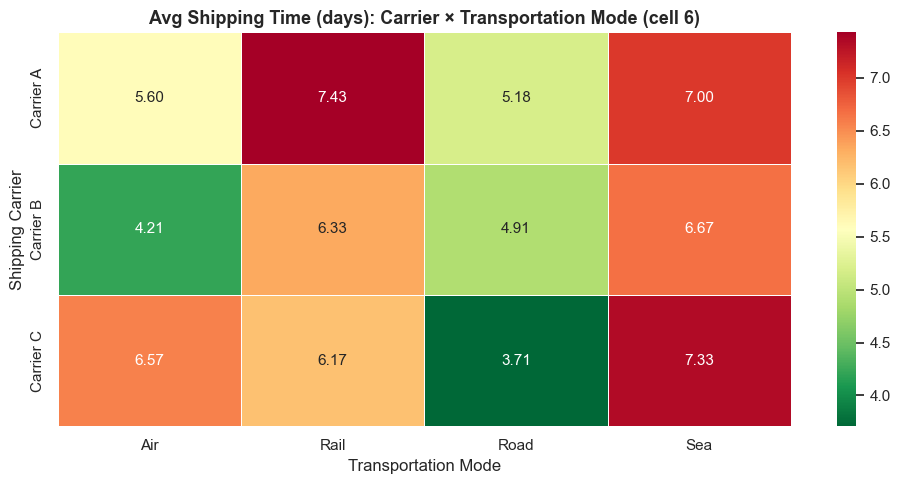

In [36]:
pivot = df.pivot_table(values='shipping_times',
                       index='shipping_carriers',
                       columns='transportation_modes',
                       aggfunc='mean').round(2)

print("📋 Avg Shipping Time — Carrier × Transport Mode:\n")
display(pivot)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, annot_kws={'size': 11})
plt.title('Avg Shipping Time (days): Carrier × Transportation Mode (cell 6)',
          fontsize=13, fontweight='bold')
plt.ylabel('Shipping Carrier')
plt.xlabel('Transportation Mode')
plt.tight_layout()
plt.show()


The heatmap of average shipping time by carrier and transportation mode 
reveals the most actionable insight of this session. When we break down 
performance at the combination level, the variance becomes dramatic:

**Best combinations (fastest delivery):**
- Carrier C + Road → **3.71 days** 🏆
- Carrier B + Air → **4.21 days**
- Carrier B + Road → **4.91 days**

**Worst combinations (slowest delivery):**
- Carrier A + Rail → **7.43 days** 🚨
- Carrier C + Sea → **7.33 days** 🚨
- Carrier A + Sea → **7.00 days** ⚠️

The gap between the best and worst combination is nearly **3.72 days** — 
meaning a product shipped via Carrier A + Rail takes almost twice as long 
to arrive as one shipped via Carrier C + Road. This is a bottleneck hiding 
in plain sight.

Notably, Carrier A consistently appears in the slowest combinations across 
multiple transport modes. This pattern suggests the issue is carrier-specific 
rather than route or mode-specific — and makes a strong case for reducing 
reliance on Carrier A.

**Session 3 Summary**


1. **Carrier B is the delivery backbone.** Fastest, cheapest, highest volume, 
   highest revenue — it should remain the primary carrier for Beautica Store.

2. **Carrier A is underperforming.** Slowest delivery, fewest shipments, 
   lowest revenue contribution. Its continued use should be justified or 
   reconsidered.

3. **Air transport is not delivering value.** It costs the most but is 
   outpaced by Road in speed. Unless there are specific use cases that 
   require it, Air shipments should be reviewed for cost efficiency.

4. **Sea is slow but cheap** — best reserved for bulk, non-time-sensitive 
   orders where the cost saving is worth the extended delivery window.

5. **Carrier A + Rail is the worst combination at 7.43 days.** This specific 
   pairing should be flagged and avoided where possible.

6. **Carrier C + Road is the sweet spot at 3.71 days.** Increasing the share 
   of shipments using this combination could meaningfully reduce average 
   delivery times across the board.


#### 3.4 Inventory & Stock Risk 

In this session, we assess Beautica Store's inventory health across its three product categories and identify which products are most at risk of stockout or overstock.

**Inventory Overview**

In [37]:
#Inventory Overview
inventory_summary = df.groupby('product_type').agg(
    avg_stock_levels   = ('stock_levels', 'mean'),
    avg_order_qty      = ('order_quantities', 'mean'),
    avg_lead_time      = ('lead_times', 'mean'),
    total_revenue      = ('revenue_generated', 'sum'),
    avg_products_sold  = ('number_of_products_sold', 'mean')
).round(2)

print("Inventory Summary by Product Type: (Cell 1) \n")
display(inventory_summary)

Inventory Summary by Product Type: (Cell 1) 



,avg_stock_levels,avg_order_qty,avg_lead_time,total_revenue,avg_products_sold
product_type,,,,,
Cosmetics,58.65,51.65,15.38,161521.27,452.19
Haircare,48.35,43.53,15.53,174455.39,400.32
Skincare,40.20,52.48,16.70,241628.16,518.28


Looking at inventory across product categories reveals a clear imbalance.

* **Skincare** has the **lowest average inventory level** (**40.20 units**) but generates the **highest revenue** (**$241,628**). This combination indicates a higher risk of stock shortages, as demand is strong while inventory remains relatively low.

* **Cosmetics** shows the opposite pattern, with the **highest inventory level** (**58.65 units**) but the **lowest revenue** (**$161,521**). This may indicate excess inventory and slower product turnover, creating opportunities to optimize stock levels.

* **Haircare** appears to have the most balanced performance, with inventory levels, order quantities, and lead times that are relatively well aligned compared to the other product categories.


**Stock Level vs Order Quantity**

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2548\652543663.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='product_type', y='stock_levels',
C:\Users\ASUS\AppData\Local\Temp\ipykernel_2548\652543663.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='product_type', y='stock_levels',
C:\Users\ASUS\AppData\Local\Temp\ipykernel_2548\652543663.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='product_type', y='order_quantities',
C:\Users\ASUS\AppData\Local\Temp\ipykernel_2548\652543663.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.bar

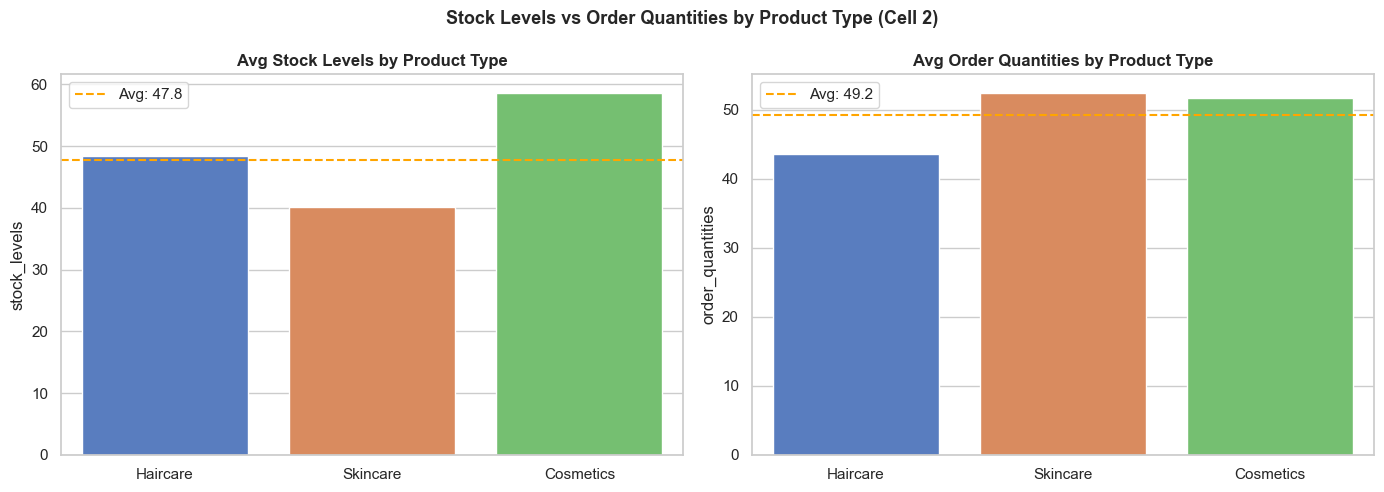

In [38]:
# Graph Stock levels by product type

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.barplot(data=df, x='product_type', y='stock_levels',
            palette='muted', ax=axes[0], ci=None)
axes[0].axhline(df['stock_levels'].mean(), color='orange',
                linestyle='--', linewidth=1.5,
                label=f"Avg: {df['stock_levels'].mean():.1f}")
axes[0].set_title('Avg Stock Levels by Product Type', fontweight='bold')
axes[0].set_xlabel('')
axes[0].legend()

# Order quantity by product type
sns.barplot(data=df, x='product_type', y='order_quantities',
            palette='muted', ax=axes[1], ci=None)
axes[1].axhline(df['order_quantities'].mean(), color='orange',
                linestyle='--', linewidth=1.5,
                label=f"Avg: {df['order_quantities'].mean():.1f}")
axes[1].set_title('Avg Order Quantities by Product Type', fontweight='bold')
axes[1].set_xlabel('')
axes[1].legend()

plt.suptitle('Stock Levels vs Order Quantities by Product Type (Cell 2)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Comparing inventory levels with order quantities provides a clearer picture of demand and replenishment across product categories.

* **Skincare** places the **second-highest average order quantity** (**52.48 units**), yet it still has the **lowest inventory level**. This suggests that customer demand is consistently higher than the current supply, increasing the risk of stock shortages.

* **Cosmetics** follows the opposite pattern. Despite already holding the **highest inventory**, it continues to place relatively high order quantities (**51.65 units**). This may indicate overstocking, where products are being replenished faster than they are sold, leading to excess inventory.


**Stock Risk Segmentation**

📋 Stock Risk Distribution by Product Type: (Cell 3)



stock_risk,Healthy,Overstock Risk,Stockout Risk
product_type,,,
Cosmetics,11,10,5
Haircare,16,9,9
Skincare,18,7,15


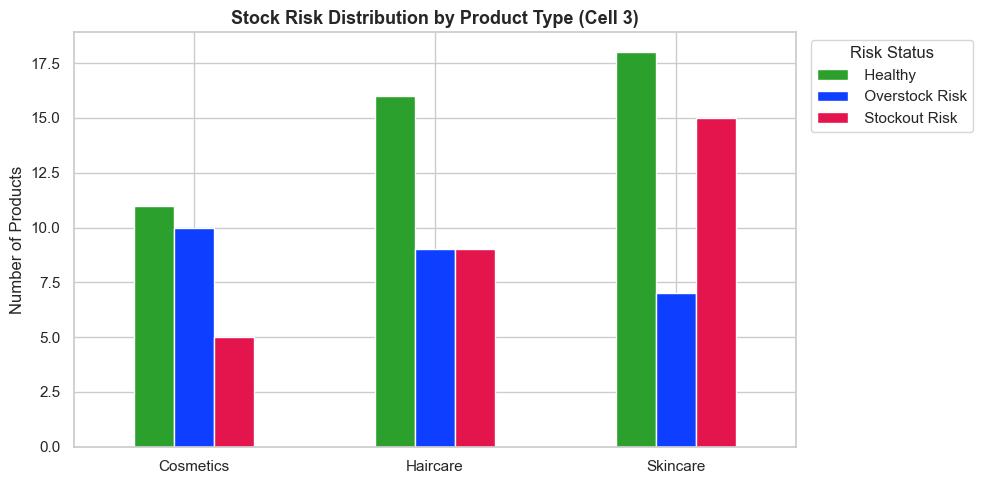

In [39]:
# Define stock risk based on stock levels vs avg sold
avg_sold = df['number_of_products_sold'].mean()
avg_stock = df['stock_levels'].mean()

def stock_risk(row):
    if row['stock_levels'] < avg_stock * 0.5:
        return ' Stockout Risk'
    elif row['stock_levels'] > avg_stock * 1.5:
        return ' Overstock Risk'
    else:
        return ' Healthy'

df['stock_risk'] = df.apply(stock_risk, axis=1)

risk_summary = df.groupby(['product_type', 'stock_risk']).size()\
                 .unstack(fill_value=0)

print("📋 Stock Risk Distribution by Product Type: (Cell 3)\n")
display(risk_summary)

risk_summary.plot(kind='bar', figsize=(10, 5),
                  color=['#2ca02c', "#0e3eff", "#e4154c"],
                  edgecolor='white')
plt.title('Stock Risk Distribution by Product Type (Cell 3)',
          fontsize=13, fontweight='bold')
plt.xlabel('')
plt.ylabel('Number of Products')
plt.xticks(rotation=0)
plt.legend(title='Risk Status', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()


Classifying products based on their inventory levels reveals two key areas that require attention.

* **Skincare** has the **highest number of products at risk of stockout**, with **15 products** falling below the recommended inventory level. Since this category also generates the highest revenue, stock shortages could lead to significant lost sales and reduced customer satisfaction.

* **Cosmetics** shows the opposite issue, with **10 products** classified as **overstock risk**—nearly **40%** of all products in the category. Excess inventory can tie up working capital, increase storage costs, and raise the risk of products becoming obsolete or requiring discounts to clear inventory.

* **Haircare** has the most balanced inventory profile, with a relatively even distribution across healthy stock levels, overstock risk, and stockout risk.


**Lead Time vs Stock Level (Scatter)**

In [40]:
df['stock_risk'].unique()

array([' Healthy', ' Stockout Risk', ' Overstock Risk'], dtype=object)

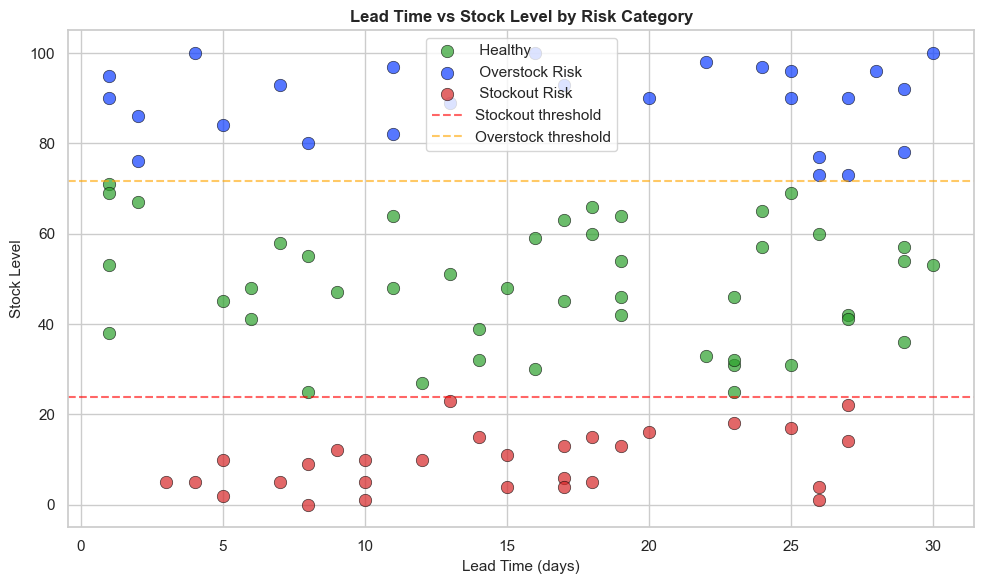

In [41]:
#Scatterplot Lead time vs stock level
fig, ax = plt.subplots(figsize=(10, 6))

colors_map = {' Stockout Risk': '#d62728',
              ' Overstock Risk': "#0e3eff",
              ' Healthy': '#2ca02c'}

for risk, group in df.groupby('stock_risk'):
    ax.scatter(group['lead_times'], group['stock_levels'],
               label=risk, color=colors_map[risk],
               alpha=0.7, s=80, edgecolors='black', linewidth=0.5)

ax.axhline(avg_stock * 0.5, color='red', linestyle='--',
           alpha=0.6, label='Stockout threshold')
ax.axhline(avg_stock * 1.5, color='orange', linestyle='--',
           alpha=0.6, label='Overstock threshold')

ax.set_xlabel('Lead Time (days)', fontsize=11)
ax.set_ylabel('Stock Level', fontsize=11)
ax.set_title('Lead Time vs Stock Level by Risk Category',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


The relationship between lead time and inventory level reveals an important insight.

* Products at **risk of stockout** are found across both short and long lead times, indicating that inventory shortages are **not primarily caused by supplier delays**. Instead, the issue is more likely related to inventory planning, such as reorder points or safety stock levels that are too low to meet demand consistently.

* Likewise, **overstocked products** are also spread across all lead time ranges, with some reaching very high inventory levels. This suggests that excess inventory is driven more by stock management decisions than by supplier lead times, resulting in inventory levels that are not well aligned with actual demand.


**Summary — Session 4**

1. **Skincare is the highest-risk category.** Lowest stock, highest 
   revenue, 15 products in stockout risk — a stockout here would hurt 
   Beautica Store the most.

2. **Cosmetics is over-stocked relative to demand.** High inventory 
   with low revenue signals slow movement and potential waste.

3. **Stockout risk is not a lead time problem.** Products across all 
   lead time ranges show stockout risk — the root cause is insufficient 
   reorder planning.

4. **Safety stock levels need to be recalibrated**, particularly for 
   Skincare, to prevent revenue loss from avoidable stockouts.

#### 3.5 Quality & Defect Impact

Quality issues are often the silent killers of supply chain efficiency. Defective products don't just create waste — they erode customer trust, inflate costs, and quietly drain revenue. In this session, we examine Beautica Store's defect landscape and estimate how much it's actually costing the business.

**Defect & Inspection Overview**

In [42]:
#Data Overview
defect_summary = df.groupby('supplier_name').agg(
    avg_defect_rate    = ('defect_rates', 'mean'),
    total_revenue      = ('revenue_generated', 'sum'),
    avg_mfg_cost       = ('manufacturing_costs', 'mean'),
    total_products     = ('sku', 'count')
).round(2).sort_values('avg_defect_rate', ascending=False)

inspection_summary = df.groupby('inspection_results').agg(
    total_products  = ('sku', 'count'),
    avg_defect_rate = ('defect_rates', 'mean'),
    total_revenue   = ('revenue_generated', 'sum'),
    avg_mfg_cost    = ('manufacturing_costs', 'mean')
).round(2)

print("\n📋 Defect Summary by Supplier: (Cell 1)\n")
display(defect_summary)
print("\n📋 Inspection Results Summary: (Cell 1)\n")
display(inspection_summary)


📋 Defect Summary by Supplier: (Cell 1)



,avg_defect_rate,total_revenue,avg_mfg_cost,total_products
supplier_name,,,,
Supplier 5,2.67,110343.46,44.77,18
Supplier 3,2.47,97795.98,43.63,15
Supplier 2,2.36,125467.42,41.62,22
Supplier 4,2.34,86468.96,62.71,18
Supplier 1,1.80,157529.00,45.25,27



📋 Inspection Results Summary: (Cell 1)



,total_products,avg_defect_rate,total_revenue,avg_mfg_cost
inspection_results,,,,
Fail,36,2.57,190565.53,52.23
Pass,23,2.04,131309.75,46.14
Pending,41,2.15,255729.54,43.54



The defect rate across suppliers ranges from **1.80%** for **Supplier 1** to **2.67%** for **Supplier 5**. Although the difference appears small, even a slight increase in defect rates can lead to substantial financial losses when applied across total sales.

The inspection results reveal an even more important concern. Out of **100 products**, only **23 products** have successfully passed inspection, while **36 products** have failed and **41 products** are still waiting for inspection.

A closer look at the financial impact shows that products with **Failed** inspection status have the **highest average manufacturing cost** (**$52.23**). In other words, Beautica Store is spending the most on products that ultimately do not meet quality standards. Meanwhile, products with **Pending** status represent the largest revenue exposure, contributing approximately **$255,730** in potential revenue. Until these products complete the inspection process, a significant portion of revenue remains uncertain and cannot be fully relied upon.


**Defect Rate by Product Type & Inspection Result**

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2548\3502528166.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='product_type', y='defect_rates',
C:\Users\ASUS\AppData\Local\Temp\ipykernel_2548\3502528166.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='product_type', y='defect_rates',


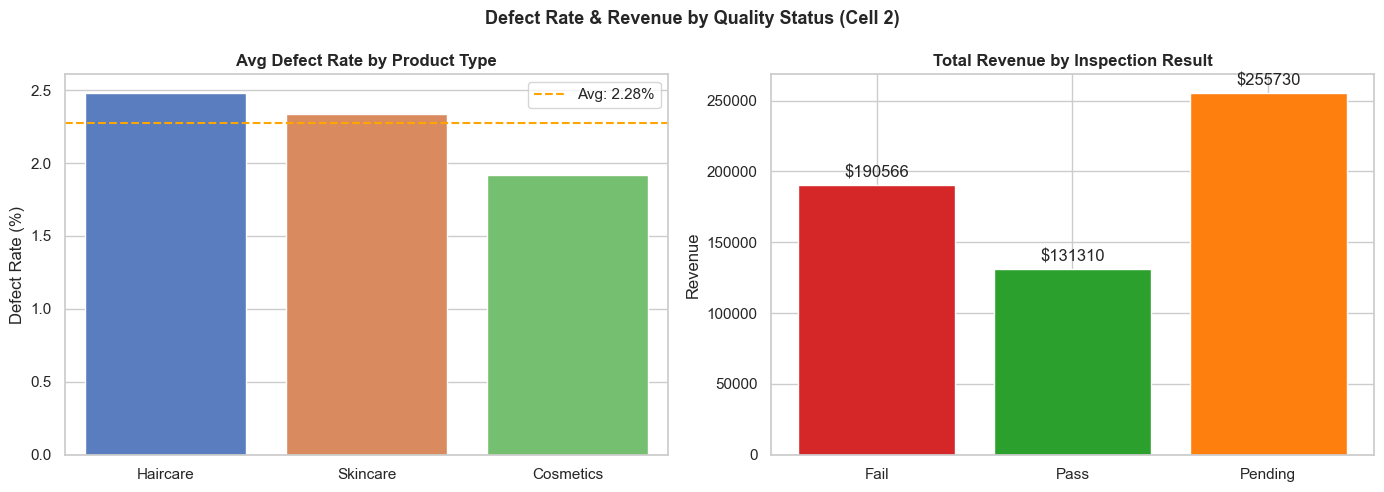

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Defect rate by product type
sns.barplot(data=df, x='product_type', y='defect_rates',
            palette='muted', ax=axes[0], ci=None)
axes[0].axhline(df['defect_rates'].mean(), color='orange',
                linestyle='--', linewidth=1.5,
                label=f"Avg: {df['defect_rates'].mean():.2f}%")
axes[0].set_title('Avg Defect Rate by Product Type', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Defect Rate (%)')
axes[0].legend()

# Revenue by inspection result
colors = {'Fail': '#d62728', 'Pass': '#2ca02c', 'Pending': '#ff7f0e'}
inspection_rev = df.groupby('inspection_results')['revenue_generated'].sum()
bars = axes[1].bar(inspection_rev.index,
                   inspection_rev.values,
                   color=[colors[x] for x in inspection_rev.index])
axes[1].bar_label(bars, fmt='$%.0f', padding=3)
axes[1].set_title('Total Revenue by Inspection Result', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Revenue')

plt.suptitle('Defect Rate & Revenue by Quality Status (Cell 2)' ,
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


The analysis shows noticeable differences in defect rates across product categories. **Haircare** has the highest defect rate at **2.47%**, followed by **Skincare** at **2.30%**, with both exceeding the overall average of **2.28%**. **Cosmetics** performs the best, recording the lowest defect rate at **1.93%**.

When comparing revenue by inspection status, a more concerning pattern emerges. Products with **Pending** inspection contribute the **highest revenue** (**$255,730**), followed by products that **Failed** inspection (**$190,566**). Meanwhile, products that have **Passed** inspection generate the **lowest revenue** (**$131,310**).

This indicates that a large portion of Beautica Store's revenue comes from products that either have not yet completed the inspection process or have already failed quality checks. These findings suggest that quality inspection may not yet be fully integrated into the product release process, increasing the risk of quality-related issues reaching customers.


**Defect Rate vs Revenue**

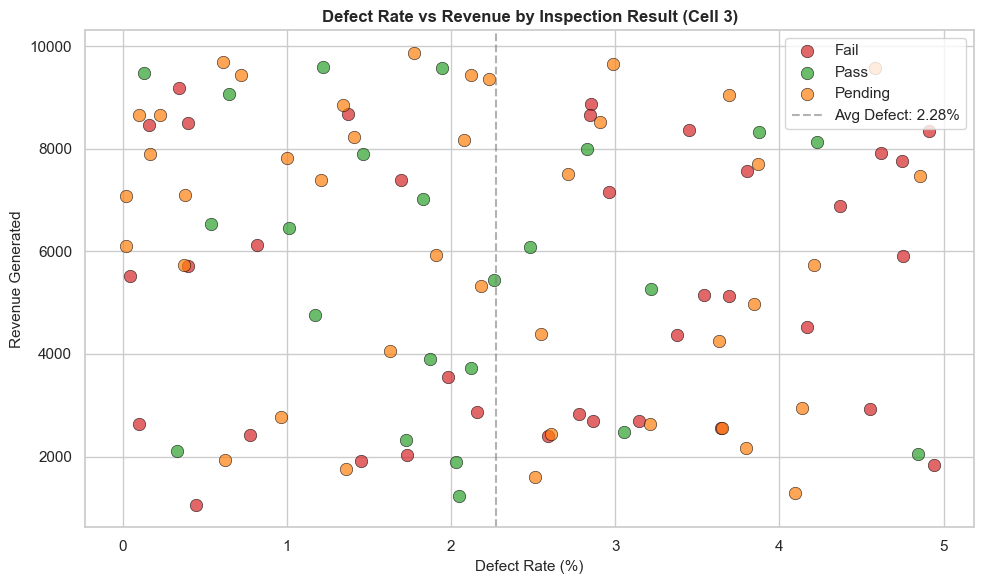

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))

colors_map = {'Fail': '#d62728', 'Pass': '#2ca02c', 'Pending': '#ff7f0e'}

for result, group in df.groupby('inspection_results'):
    ax.scatter(group['defect_rates'], group['revenue_generated'],
               label=result, color=colors_map[result],
               alpha=0.7, s=80, edgecolors='black', linewidth=0.5)

ax.axvline(df['defect_rates'].mean(), color='gray', linestyle='--',
           alpha=0.6, label=f"Avg Defect: {df['defect_rates'].mean():.2f}%")

ax.set_xlabel('Defect Rate (%)', fontsize=11)
ax.set_ylabel('Revenue Generated', fontsize=11)
ax.set_title('Defect Rate vs Revenue by Inspection Result (Cell 3)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


The scatter plot shows that there is **no clear relationship** between defect rate and revenue. Products with relatively **high defect rates** can still generate strong sales, while some products with **low defect rates** contribute relatively little revenue.

This suggests that, in the short term, product quality does not appear to have a direct impact on sales performance. However, this should not be interpreted as a positive sign. If quality issues continue, they could eventually lead to customer complaints, product returns, and a decline in customer trust, all of which may negatively affect revenue in the long run.


**Estimated Revenue Loss from Defects**

📋 Estimated Revenue Loss by Supplier:



,estimated_loss
supplier_name,
Supplier 2,2865.73
Supplier 1,2839.95
Supplier 5,2645.58
Supplier 3,2257.50
Supplier 4,2048.68



📋 Estimated Revenue Loss by Product Type:



,estimated_loss
product_type,
Skincare,5461.75
Haircare,3958.23
Cosmetics,3237.46


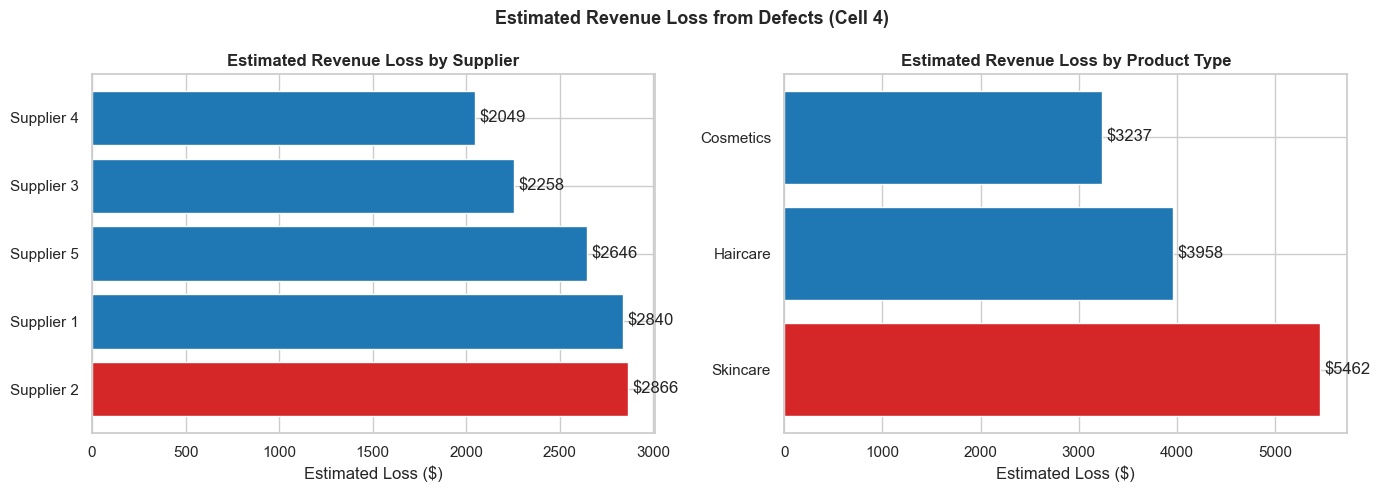

In [45]:
# Estimate revenue loss: defect_rate × revenue per product
df['estimated_loss'] = (df['defect_rates'] / 100) * df['revenue_generated']

loss_by_supplier = df.groupby('supplier_name')['estimated_loss']\
                     .sum().round(2).sort_values(ascending=False)
loss_by_product  = df.groupby('product_type')['estimated_loss']\
                     .sum().round(2).sort_values(ascending=False)

print("📋 Estimated Revenue Loss by Supplier:\n")
display(loss_by_supplier.to_frame())
print("\n📋 Estimated Revenue Loss by Product Type:\n")
display(loss_by_product.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_s = ['#d62728' if x == loss_by_supplier.max()
            else '#1f77b4' for x in loss_by_supplier]
bars1 = axes[0].barh(loss_by_supplier.index,
                     loss_by_supplier.values, color=colors_s)
axes[0].bar_label(bars1, fmt='$%.0f', padding=3)
axes[0].set_title('Estimated Revenue Loss by Supplier', fontweight='bold')
axes[0].set_xlabel('Estimated Loss ($)')

colors_p = ['#d62728' if x == loss_by_product.max()
            else '#1f77b4' for x in loss_by_product]
bars2 = axes[1].barh(loss_by_product.index,
                     loss_by_product.values, color=colors_p)
axes[1].bar_label(bars2, fmt='$%.0f', padding=3)
axes[1].set_title('Estimated Revenue Loss by Product Type', fontweight='bold')
axes[1].set_xlabel('Estimated Loss ($)')

plt.suptitle('Estimated Revenue Loss from Defects (Cell 4)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Estimating the financial impact of product defects reveals that even relatively small defect rates can result in meaningful revenue losses.

**By supplier:**

* **Supplier 2** has the **highest estimated revenue loss** at approximately **$2,866**. Although it does not have the highest defect rate, the large number of products it supplies increases its overall financial impact.
* **Supplier 1** follows closely with an estimated loss of **$2,840**. Its low defect rate is offset by its large product portfolio, leading to a similar level of potential loss.
* **Supplier 4** records the **lowest estimated loss** (**$2,049**), mainly because it supplies fewer products than the others.

**By product category:**

* **Skincare** contributes the **largest estimated revenue loss** at around **$5,462**, driven by its high sales volume combined with an above-average defect rate.
* **Haircare** and **Cosmetics** follow with estimated losses of **$3,958** and **$3,237**, respectively.

Overall, product defects are estimated to result in approximately **$12,657** in lost revenue. Strengthening quality control processes and ensuring products complete inspection before release could help reduce these losses and improve overall business performance.


#### 3.6 Cost Inefficiency

Every dollar spent inefficiently in a supply chain is a dollar that 
could have gone to growth. In this final analysis session, we break 
down Beautica Store's cost structure across products, suppliers, and 
logistics — and identify where money is being spent without proportional 
return.

**Cost Overview**

In [46]:
#Overview

cost_summary = df.groupby('product_type').agg(
    avg_mfg_cost      = ('manufacturing_costs', 'mean'),
    avg_shipping_cost = ('shipping_costs', 'mean'),
    avg_total_cost    = ('total_cost', 'mean'),
    avg_revenue       = ('revenue_generated', 'mean'),
    avg_profit        = ('profit', 'mean'),
    avg_margin        = ('profit_margin_pct', 'mean')
).round(2)

supplier_cost = df.groupby('supplier_name').agg(
    avg_mfg_cost      = ('manufacturing_costs', 'mean'),
    avg_shipping_cost = ('shipping_costs', 'mean'),
    avg_total_cost    = ('total_cost', 'mean'),
    avg_revenue       = ('revenue_generated', 'mean'),
    avg_profit        = ('profit', 'mean'),
    avg_margin        = ('profit_margin_pct', 'mean')
).round(2).sort_values('avg_total_cost', ascending=False)

print(" Cost Summary by Product Type:\n")
display(cost_summary)
print(" Cost Summary by Supplier:\n")
display(supplier_cost)

 Cost Summary by Product Type:



,avg_mfg_cost,avg_shipping_cost,avg_total_cost,avg_revenue,avg_profit,avg_margin
product_type,,,,,,
Cosmetics,43.05,6.06,49.11,6212.36,6163.24,99.02
Haircare,48.46,5.91,54.37,5131.04,5076.68,98.41
Skincare,48.99,4.91,53.90,6040.70,5986.80,98.54


 Cost Summary by Supplier:



,avg_mfg_cost,avg_shipping_cost,avg_total_cost,avg_revenue,avg_profit,avg_margin
supplier_name,,,,,,
Supplier 4,62.71,5.76,68.47,4803.83,4735.36,98.13
Supplier 1,45.25,5.51,50.77,5834.41,5783.64,98.63
Supplier 5,44.77,5.79,50.56,6130.19,6079.63,98.47
Supplier 3,43.63,4.79,48.42,6519.73,6471.31,98.99
Supplier 2,41.62,5.74,47.36,5703.06,5655.70,98.89



The cost analysis reveals clear differences in efficiency across both product categories and suppliers.

* **Cosmetics** is the **most cost-efficient product category**. It has the **lowest manufacturing and total costs**, while generating the **highest average revenue** and maintaining the **highest profit margin**. This indicates that Cosmetics delivers the best return relative to its production costs.

* **Haircare** presents the opposite trend. Despite having relatively **high manufacturing costs**, it generates the **lowest average revenue**, suggesting there is room to improve its cost efficiency and profitability.

* At the supplier level, **Supplier 4** stands out as the least efficient. It has the **highest total cost**, yet produces the **lowest average revenue** and the **lowest profit margin**. This reinforces previous findings that Supplier 4 is a major cost concern and should be prioritized for performance review.

* In contrast, **Supplier 3** is the **most cost-efficient supplier**, recording the **lowest total cost** while achieving the **highest average revenue**. This demonstrates that lower operating costs can be achieved without sacrificing business performance.


**Cost Breakdown by Product Type**

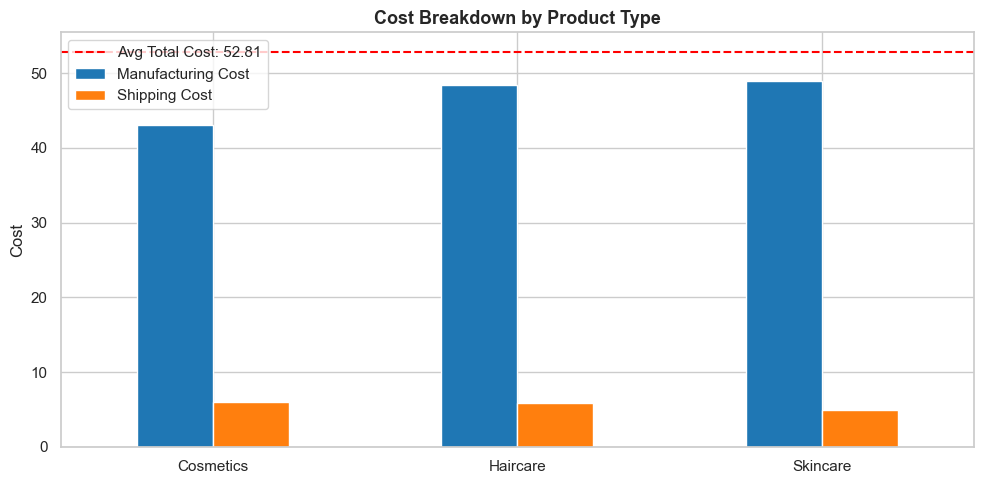

In [47]:
#Cost Breakdown by Product Type

cost_cols = ['avg_mfg_cost', 'avg_shipping_cost']
cost_plot = cost_summary[cost_cols].copy()
cost_plot.columns = ['Manufacturing Cost', 'Shipping Cost']

cost_plot.plot(kind='bar', figsize=(10, 5),
               color=['#1f77b4', '#ff7f0e'],
               edgecolor='white')

plt.axhline(df['total_cost'].mean(), color='red', linestyle='--',
            linewidth=1.5, label=f"Avg Total Cost: {df['total_cost'].mean():.2f}")
plt.title('Cost Breakdown by Product Type', fontsize=13, fontweight='bold')
plt.xlabel('')
plt.ylabel('Cost')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()


The cost breakdown shows that **manufacturing is the largest contributor to total costs** across all product categories, accounting for approximately **88–90%** of overall expenses. In comparison, **shipping costs** represent only around **10–12%** of the total.

This means that the greatest opportunity for cost savings lies in improving **manufacturing efficiency** and negotiating better production costs with suppliers. While optimizing shipping costs may still provide some benefits, its overall impact on reducing total expenses is relatively limited compared to improvements in manufacturing.


**Manufacturing Cost vs Revenue by Supplier**

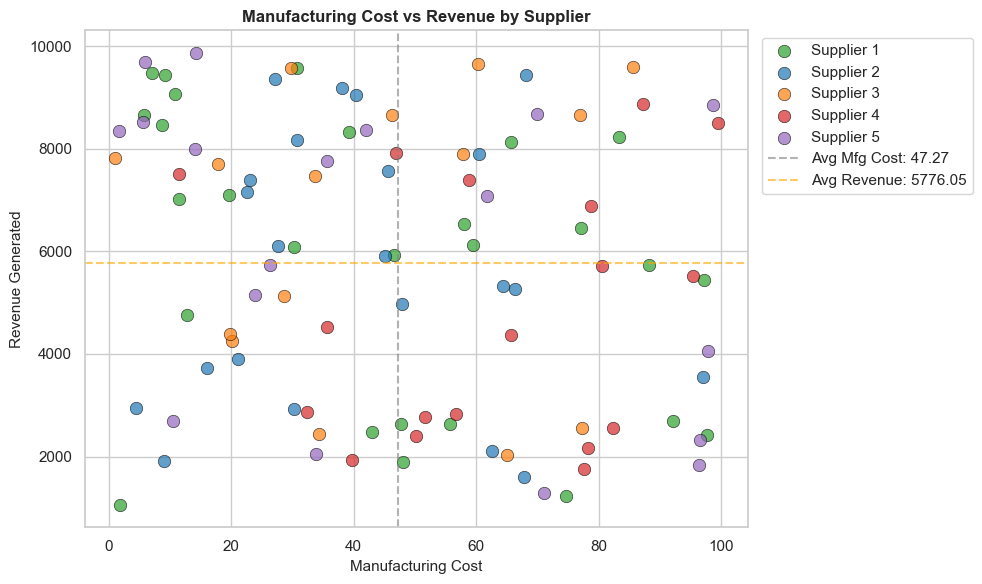

In [48]:

fig, ax = plt.subplots(figsize=(10, 6))

colors_map = {
    'Supplier 1': '#2ca02c',
    'Supplier 2': '#1f77b4',
    'Supplier 3': '#ff7f0e',
    'Supplier 4': '#d62728',
    'Supplier 5': '#9467bd'
}

for supplier, group in df.groupby('supplier_name'):
    ax.scatter(group['manufacturing_costs'], group['revenue_generated'],
               label=supplier, color=colors_map[supplier],
               alpha=0.7, s=80, edgecolors='black', linewidth=0.5)

ax.axvline(df['manufacturing_costs'].mean(), color='gray', linestyle='--',
           alpha=0.6, label=f"Avg Mfg Cost: {df['manufacturing_costs'].mean():.2f}")
ax.axhline(df['revenue_generated'].mean(), color='orange', linestyle='--',
           alpha=0.6, label=f"Avg Revenue: {df['revenue_generated'].mean():.2f}")

ax.set_xlabel('Manufacturing Cost', fontsize=11)
ax.set_ylabel('Revenue Generated', fontsize=11)
ax.set_title('Manufacturing Cost vs Revenue by Supplier',
             fontsize=12, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


The scatter plot shows that there is **no strong relationship** between manufacturing cost and revenue. Products with both high and low production costs can generate either high or low revenue, indicating that production cost alone does not determine sales performance.

However, several supplier-level patterns stand out:

* **Supplier 1** consistently delivers the best value, with many of its products falling into the **low-cost, high-revenue** category. This indicates strong cost efficiency and overall supplier performance.

* **Supplier 4** displays the opposite trend. Its products generally have **high manufacturing costs**, yet many generate relatively **low revenue**. This reinforces earlier findings that Supplier 4 is the least cost-efficient supplier and has the greatest negative impact on profitability.

* **Supplier 3** frequently appears in the **high-revenue** segment despite varying production costs, suggesting that its products perform well in the market and are able to generate strong revenue regardless of manufacturing expenses.


**Cost Efficiency by Transportation Mode & Route**

📋 Cost by Transportation Mode:



,avg_shipping_cost,avg_total_cost,avg_revenue
transportation_modes,,,
Air,6.02,48.38,5989.82
Road,5.54,59.19,5493.63
Rail,5.47,55.01,5892.51
Sea,4.97,45.10,5739.05



📋 Cost by Route:



,avg_shipping_cost,avg_total_cost,avg_revenue
routes,,,
Route C,5.90,47.30,5996.10
Route B,5.55,51.95,5526.59
Route A,5.38,56.12,5888.35


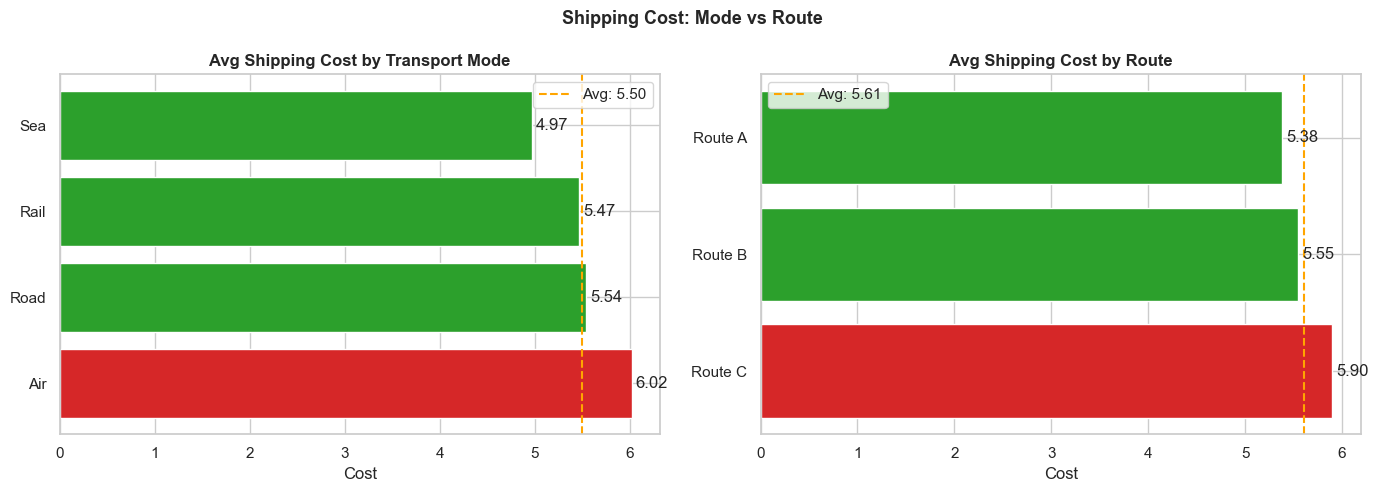

In [49]:

mode_cost = df.groupby('transportation_modes').agg(
    avg_shipping_cost = ('shipping_costs', 'mean'),
    avg_total_cost    = ('total_cost', 'mean'),
    avg_revenue       = ('revenue_generated', 'mean')
).round(2).sort_values('avg_shipping_cost', ascending=False)

route_cost = df.groupby('routes').agg(
    avg_shipping_cost = ('shipping_costs', 'mean'),
    avg_total_cost    = ('total_cost', 'mean'),
    avg_revenue       = ('revenue_generated', 'mean')
).round(2).sort_values('avg_shipping_cost', ascending=False)


print("📋 Cost by Transportation Mode:\n")
display(mode_cost)
print("\n📋 Cost by Route:\n")
display(route_cost)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_m = ['#d62728' if x == mode_cost['avg_shipping_cost'].max()
            else '#2ca02c' for x in mode_cost['avg_shipping_cost']]
bars1 = axes[0].barh(mode_cost.index,
                     mode_cost['avg_shipping_cost'], color=colors_m)
axes[0].axvline(mode_cost['avg_shipping_cost'].mean(), color='orange',
                linestyle='--', linewidth=1.5,
                label=f"Avg: {mode_cost['avg_shipping_cost'].mean():.2f}")
axes[0].bar_label(bars1, fmt='%.2f', padding=3)
axes[0].set_title('Avg Shipping Cost by Transport Mode', fontweight='bold')
axes[0].set_xlabel('Cost')
axes[0].legend()

colors_r = ['#d62728' if x == route_cost['avg_shipping_cost'].max()
            else '#2ca02c' for x in route_cost['avg_shipping_cost']]
bars2 = axes[1].barh(route_cost.index,
                     route_cost['avg_shipping_cost'], color=colors_r)
axes[1].axvline(route_cost['avg_shipping_cost'].mean(), color='orange',
                linestyle='--', linewidth=1.5,
                label=f"Avg: {route_cost['avg_shipping_cost'].mean():.2f}")
axes[1].bar_label(bars2, fmt='%.2f', padding=3)
axes[1].set_title('Avg Shipping Cost by Route', fontweight='bold')
axes[1].set_xlabel('Cost')
axes[1].legend()

plt.suptitle('Shipping Cost: Mode vs Route', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


The logistics cost analysis highlights several opportunities to improve transportation efficiency.

* **Air** is the **most expensive shipping mode**, yet previous analysis showed that **Road** actually provides faster delivery. This suggests that using Air does not always offer sufficient benefits to justify its higher shipping cost.

* **Sea** is the **lowest-cost transportation mode** and also results in the **lowest total cost**, making it the most suitable option for shipments where delivery speed is not a priority.

* Route analysis reveals an interesting pattern. **Route A** has the **lowest shipping cost** but the **highest total cost**, while **Route C** has the **highest shipping cost** yet records the **lowest total cost** and the **highest average revenue**.

* These findings indicate that shipping cost alone does not determine overall logistics efficiency. Other factors, such as product mix, handling processes, or operational activities along each route, likely play an important role in influencing total costs and business performance.


**Cost vs Profit Margin**

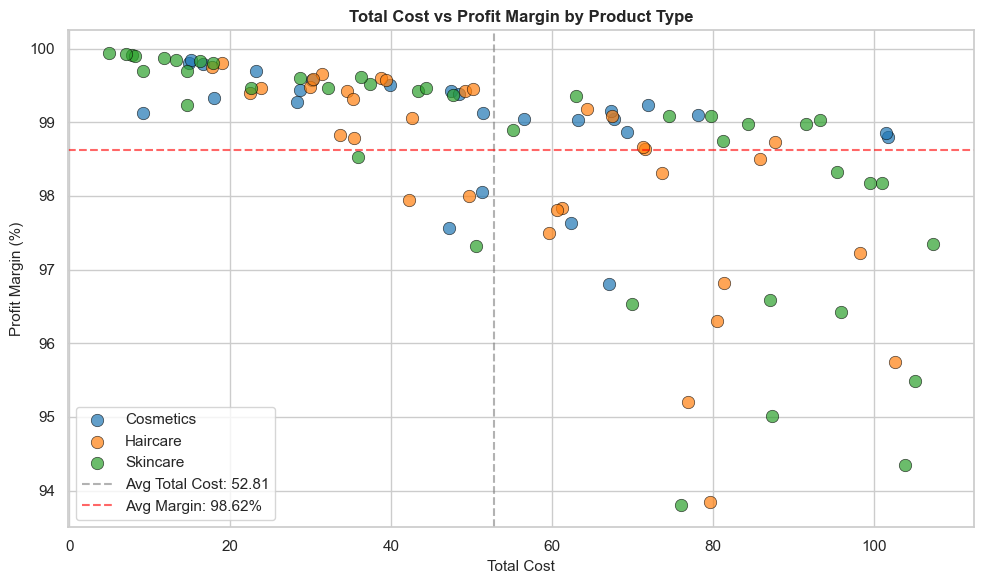

In [50]:
#Cell 5
fig, ax = plt.subplots(figsize=(10, 6))

colors_type = {'Cosmetics': '#1f77b4',
               'Haircare': '#ff7f0e',
               'Skincare': '#2ca02c'}

for ptype, group in df.groupby('product_type'):
    ax.scatter(group['total_cost'], group['profit_margin_pct'],
               label=ptype, color=colors_type[ptype],
               alpha=0.7, s=80, edgecolors='black', linewidth=0.5)

ax.axvline(df['total_cost'].mean(), color='gray', linestyle='--',
           alpha=0.6, label=f"Avg Total Cost: {df['total_cost'].mean():.2f}")
ax.axhline(df['profit_margin_pct'].mean(), color='red', linestyle='--',
           alpha=0.6, label=f"Avg Margin: {df['profit_margin_pct'].mean():.2f}%")

ax.set_xlabel('Total Cost', fontsize=11)
ax.set_ylabel('Profit Margin (%)', fontsize=11)
ax.set_title('Total Cost vs Profit Margin by Product Type',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


The scatter plot shows a **clear negative relationship** between total cost and profit margin. As total costs increase, profit margins tend to decrease. Products with lower total costs generally maintain profit margins above **99%**, while higher-cost products experience a noticeable decline in profitability.

Although the average profit margin across the dataset remains high at **98.62%**, the overall trend suggests that rising costs will gradually reduce profitability if left unmanaged. Improving cost efficiency, particularly in manufacturing and supplier operations, will be important to maintain healthy margins.

Among all product categories, **Skincare** experiences the greatest decline in profit margin at higher cost levels. Combined with previous findings—such as its high stockout risk and the largest estimated revenue loss from defects—this reinforces that Skincare should be prioritized for operational improvements.


**Key Summary 'Cost Inefficiency'** 

* **Supplier 4 requires immediate attention.** It records the highest total cost while generating the lowest revenue and profit margin, making it the least cost-efficient supplier in the network.

* **Supplier 3 is the most cost-efficient supplier.** With the lowest total cost and the highest average revenue, its operational practices could serve as a benchmark for improving other suppliers.

* **Manufacturing cost is the main driver of total expenses.** Since it accounts for around **88–90%** of overall costs, improving production efficiency and negotiating supplier costs will have a much greater impact than reducing shipping expenses.

* **The use of Air transportation should be re-evaluated.** Despite being the most expensive shipping mode, it does not provide a clear speed advantage over Road transportation, making its cost-effectiveness questionable.

* **Route C delivers the best overall performance.** Although its shipping cost is slightly higher, it achieves the lowest total cost and the highest average revenue, making it the most efficient route overall.

* **Controlling costs is essential to maintaining profitability.** The analysis consistently shows that higher total costs lead to lower profit margins, highlighting the importance of cost management as Beautica Store continues to grow.


---

# Chapter 4 — Insights & Recommendations

---

## 4.1 Executive Summary

This analysis was carried out as part of an operational audit requested by Beautica Store's investors. Using data from **100 SKUs**, we evaluated six key areas of the supply chain, including **supplier performance, shipping and delivery, inventory management, product quality, and cost efficiency**.

The results reveal several important issues that are affecting the overall performance of the supply chain. These bottlenecks are reducing operational efficiency and limiting profitability, even though they may not be immediately visible in day-to-day operations. The good news is that these challenges can be addressed through targeted, data-driven improvements, providing clear opportunities for Beautica Store to optimize its supply chain and improve business performance.


## 4.2 Key Findings Summary

| # | Area | Finding | Severity |
|---|---|---|---|
| 1 | Supplier Performance | Only Supplier 1 is rated Good. 4 out of 5 suppliers are underperforming on quality, cost, or speed | 🔴 High |
| 2 | Supplier Cost | Supplier 4 costs 32% more than average but delivers the lowest revenue and highest fail rate | 🔴 High |
| 3 | Delivery | Carrier A + Rail is the slowest combination at 7.43 days — nearly 2x the fastest option | 🟡 Medium |
| 4 | Delivery | Air transport is the most expensive mode yet slower than Road | 🟡 Medium |
| 5 | Inventory | Skincare has 15 products in stockout risk zone despite being the highest revenue category | 🔴 High |
| 6 | Inventory | Cosmetics has 10 products in overstock risk — capital tied up in slow-moving stock | 🟡 Medium |
| 7 | Quality | Only 23% of products passed inspection — 36 failed, 41 still pending | 🔴 High |
| 8 | Quality | Products with Fail status still generate $190K in revenue — quality gate is not enforced | 🔴 High |
| 9 | Quality | Estimated total revenue loss from defects is ~$12,657 | 🟡 Medium |
| 10 | Cost | Supplier 4 total cost (68.47) is 44% above the most efficient supplier (Supplier 3 at 48.42) | 🔴 High |
| 11 | Cost | Manufacturing cost accounts for 88–90% of total cost — shipping is not the main cost driver | 🟢 Informational |
| 12 | Cost | Higher total cost consistently compresses profit margins across all product types | 🟡 Medium |


## 4.3 Recommendations

### 🏭 R1 — Conduct an Immediate Audit of Supplier 4

**Finding:**
The analysis identifies **Supplier 4** as the weakest-performing supplier. It has the **highest manufacturing cost**, the **highest inspection fail rate** (around **67%**), and contributes the **lowest revenue** among all suppliers. This combination indicates that Beautica Store is spending more while receiving relatively poor returns.

**Recommendation:**
Carry out a comprehensive performance audit of Supplier 4 to identify the root causes of its high costs and quality issues. The audit should focus on production processes, quality control practices, and overall cost efficiency. If there is no clear improvement within the agreed timeline, Beautica Store should consider shifting its orders to better-performing suppliers.

**Action Items:**

* Conduct a supplier performance audit within the next **30 days**.
* Establish clear improvement targets, including reducing the **defect rate below 2%**, lowering the **inspection fail rate below 30%**, and achieving at least a **15% reduction in manufacturing costs**.
* Review Supplier 4's performance after **90 days**. If the agreed targets are not achieved, begin evaluating alternative suppliers.
* Gradually transfer part of Supplier 4's product volume to stronger suppliers, such as **Supplier 1** or **Supplier 2**, to minimize operational risk during the transition.




### 🔍 R2 — Strengthen Quality Inspection Process

**Finding:**
The inspection analysis shows that only **23 out of 100 products** have successfully passed quality inspection. Meanwhile, **36 products** that failed inspection are still associated with approximately **$190,566** in revenue, and **41 products** remain in **Pending** status, representing around **$255,730** in potential revenue. This indicates that the current inspection process is not effectively controlling product quality before products move through the supply chain.

**Recommendation:**
Strengthen the quality inspection process by ensuring that products failing inspection cannot proceed to the next stage until quality issues are resolved. At the same time, reduce the backlog of Pending inspections to minimize uncertainty and improve inventory visibility.

**Action Items:**

* Prevent products with **Fail** inspection status from moving into the sales or distribution process until they meet quality standards.
* Set a target of **no more than 7 days** for products to remain in **Pending** inspection status.
* Assign additional quality control resources to clear the existing Pending backlog as quickly as possible.
* Establish monthly inspection performance targets for each supplier, with a minimum **50% inspection pass rate**.
* Continuously monitor supplier defect rates using a rolling **3-month performance review** to identify quality trends and take corrective action early.


### 📦 R3 — Optimize Skincare Inventory Management

**Finding:**
**Skincare** is the highest-performing product category in terms of revenue (**$241,628**), but it also has the **lowest average inventory level** and the **highest number of products at risk of stockout**. The analysis indicates that this issue is **not caused by supplier lead times**, but rather by inventory planning and reorder policies that are not keeping pace with customer demand.

**Recommendation:**
Improve inventory planning for Skincare by increasing safety stock levels and implementing a more dynamic reorder system that adjusts to changes in demand. This will help reduce the risk of stock shortages while maintaining product availability.

**Action Items:**

* Increase the minimum inventory level for **Skincare** products by at least **30%**.
* Calculate reorder points based on **average daily demand**, **supplier lead time**, and an appropriate **safety stock buffer**.
* Implement automated low-stock alerts to notify the inventory team when Skincare products fall below the target stock level.
* Review inventory levels and reorder quantities on a **monthly basis**, adjusting them according to recent sales trends and demand patterns.


### 🗄️ R4 — Reduce Cosmetics Overstock

**Finding:** Cosmetics has 10 products (nearly 40% of its range) in 
the overstock risk zone, with the highest stock levels (58.65) but 
the lowest revenue ($161,521). Excess inventory ties up working capital 
and increases the risk of product expiry.

**Recommendation:** Reduce order quantities for slow-moving Cosmetics 
SKUs and introduce demand-based ordering to prevent further accumulation.

**Action Items:**
- Identify the specific Cosmetics SKUs in overstock and halt 
  reordering until stock normalizes
- Introduce promotional pricing or bundling to accelerate sell-through 
  of overstocked items
- Shift to smaller, more frequent orders for Cosmetics to reduce 
  overstock buildup
- Set a maximum stock level cap per Cosmetics SKU

### 🚚 R5 — Optimize Carrier & Transportation Mode Selection

**Finding:** Carrier A is the slowest carrier (6.14 days) with the 
lowest revenue contribution ($142,629). The Carrier A + Rail combination 
is the worst pairing in the entire dataset at 7.43 days. Meanwhile, 
Air transport costs the most (6.02) yet is slower than Road (4.72 days).

**Recommendation:** Shift shipment volume away from Carrier A and 
reduce reliance on Air transport. Prioritize Carrier B for standard 
shipments and maximize use of the Carrier C + Road combination for 
time-sensitive deliveries.

**Action Items:**
- Eliminate the Carrier A + Rail combination from the routing plan 
  immediately
- Conduct a cost-benefit review of all Air transport usage — replace 
  with Road where speed difference is negligible
- Set Carrier B as the default carrier for all standard shipments
- Increase the share of Carrier C + Road for priority deliveries 
  (current best time: 3.71 days)
- Renegotiate or terminate the contract with Carrier A if performance 
  does not improve

### 💸 R6 — Improve Manufacturing Cost Efficiency

**Finding:**
Manufacturing accounts for **88–90%** of total operating costs, making it the largest cost driver in the supply chain. **Supplier 4** has the highest manufacturing cost, while **Supplier 3** achieves the lowest cost with strong business performance. The analysis also confirms that higher production costs consistently reduce profit margins.

**Recommendation:**
Focus cost-reduction efforts on manufacturing by renegotiating prices with high-cost suppliers and adopting best practices from the most cost-efficient suppliers.

**Action Items:**

* Begin cost negotiations with **Supplier 4**, targeting at least a **20% reduction** in manufacturing costs.
* Use **Supplier 3** as the benchmark when evaluating supplier cost efficiency.
* Consider increasing purchase volumes from **Supplier 3** to benefit from economies of scale.
* Prioritize **Route C** where appropriate, as it delivers the lowest total cost while generating the highest average revenue.


## 4.4 Priority Action Plan

| Priority | Recommendation | Timeline | Expected Impact |
|---|---|---|---|
| 🔴 P1 | Audit & review Supplier 4 | 0–30 days | Cost reduction, quality improvement |
| 🔴 P2 | Enforce quality gate — block Fail products from sales | 0–30 days | Stop revenue leakage from defective products |
| 🔴 P3 | Recalibrate Skincare safety stock & reorder points | 0–30 days | Prevent stockout on highest revenue category |
| 🟡 P4 | Clear Pending inspection backlog | 30–60 days | Reduce $255K revenue uncertainty |
| 🟡 P5 | Eliminate Carrier A + Rail combination | 30–60 days | Reduce average delivery time |
| 🟡 P6 | Reduce Cosmetics overstock via demand-based ordering | 30–60 days | Free up working capital |
| 🟢 P7 | Renegotiate manufacturing costs with Supplier 4 | 60–90 days | Long-term margin improvement |
| 🟢 P8 | Review and reduce Air transport usage | 60–90 days | Shipping cost optimization |

## 4.5 Closing Note

> *"A strong supply chain is built by continuously improving its weakest points. Identifying those areas is the first step—taking action is what drives lasting improvement."*

The analysis shows that **Beautica Store's supply chain is performing well in many areas, but several operational challenges still need attention**. While these issues are not critical today, they have the potential to grow alongside the business if left unresolved. Addressing them early will help the company build a more efficient, resilient, and scalable supply chain.

The recommendations presented in this report are based on data and focus on the areas with the greatest potential impact, from supplier performance and inventory management to quality control, logistics, and cost optimization. By implementing these improvements in a structured and prioritized way, Beautica Store can strengthen its operational performance while demonstrating to investors that its future growth is supported by a well-managed and data-driven supply chain.
